# Building a Live Market Data Pipeline

---

## Executive Summary

This notebook develops a complete market data quality pipeline from first principles. We fetch real stock data, build validation layers, implement robust outlier detection for fat-tailed distributions, handle corporate actions (splits and dividends), and assemble a full automated quality framework.

**Key Deliverables:**
1. OHLCV data loading and structural validation
2. Return computation (simple and logarithmic) and realized volatility estimation
3. Missing data detection, classification, and intelligent gap filling
4. Robust outlier detection using Median Absolute Deviation (MAD)
5. Corporate action adjustments for stock splits and cash dividends
6. Full automated quality pipeline with scoring and reporting
7. Extensions and research directions for production systems

---

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Fetching and Loading Real Market Data](#2-fetching-and-loading-real-market-data)
3. [Return Computation and Volatility Estimation](#3-return-computation-and-volatility-estimation)
4. [OHLCV Structural Validation](#4-ohlcv-structural-validation)
5. [Missing Data Detection and Gap Filling](#5-missing-data-detection-and-gap-filling)
6. [Outlier Detection for Fat-Tailed Data](#6-outlier-detection-for-fat-tailed-data)
7. [Corporate Action Adjustments](#7-corporate-action-adjustments)
8. [Full Quality Pipeline](#8-full-quality-pipeline)
9. [Multi-Ticker Analysis](#9-multi-ticker-analysis)
10. [Extensions and Research Directions](#10-extensions-and-research-directions)
11. [References](#11-references)

## 1. Environment Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# For fetching real data
import yfinance as yf

# Plot styling - dark professional theme
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Color palette
COLORS = {
    'primary': '#26804a',
    'secondary': '#339b5e',
    'accent': '#56b67d',
    'light': '#8dd1a8',
    'red': '#f85149',
    'orange': '#f0883e',
    'blue': '#58a6ff',
    'purple': '#bc8cff',
    'gray': '#8b949e',
    'white': '#e6edf3',
}

print('Environment ready.')
print(f'NumPy {np.__version__}, Pandas {pd.__version__}')

Environment ready.
NumPy 2.2.6, Pandas 2.2.3


## 2. Fetching and Loading Real Market Data

### 2.1 The OHLCV Standard

Market data for equities, futures, and most tradeable instruments comes in **OHLCV** format:

| Field | Symbol | Description |
|-------|--------|-------------|
| Open | $O_t$ | First traded price of the period |
| High | $H_t$ | Highest traded price during the period |
| Low | $L_t$ | Lowest traded price during the period |
| Close | $C_t$ | Last traded price of the period |
| Volume | $V_t$ | Total shares/contracts traded |

OHLCV data has inherent structural constraints:

$$L_t \leq O_t \leq H_t \quad \text{and} \quad L_t \leq C_t \leq H_t \quad \text{and} \quad V_t \geq 0$$

Violations of these constraints indicate data errors.

### 2.2 Fetching Data with yfinance

At institutional firms, data comes from vendors like Bloomberg, Refinitiv, or exchange direct feeds. For this notebook, we use `yfinance` to access Yahoo Finance data. The principles are identical regardless of the data source.

In [2]:
def fetch_ohlcv(ticker: str, period: str = '2y') -> pd.DataFrame:
    """
    Fetch daily OHLCV data for a given ticker.
    
    Parameters
    ----------
    ticker : str
        Stock symbol (e.g., 'AAPL', 'MSFT')
    period : str
        Data period ('6mo', '1y', '2y', '5y', 'max')
    
    Returns
    -------
    pd.DataFrame
        OHLCV DataFrame with DatetimeIndex
    """
    stock = yf.Ticker(ticker)
    df = stock.history(period=period)
    
    # Keep only OHLCV columns
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.index = pd.to_datetime(df.index.date)  # Remove timezone info
    df.index.name = 'Date'
    
    return df


# Fetch 2 years of daily data for several tickers
tickers = ['AAPL', 'MSFT', 'TSLA', 'GOOG']
data = {}

for ticker in tickers:
    data[ticker] = fetch_ohlcv(ticker, period='2y')
    print(f'{ticker}: {len(data[ticker])} trading days '
          f'({data[ticker].index[0].strftime("%Y-%m-%d")} to '
          f'{data[ticker].index[-1].strftime("%Y-%m-%d")})')

# Use AAPL as our primary working example
df = data['AAPL'].copy()
print(f'\nAAPL sample:')
df.head(10)

AAPL: 502 trading days (2024-04-03 to 2026-04-02)
MSFT: 502 trading days (2024-04-03 to 2026-04-02)
TSLA: 502 trading days (2024-04-03 to 2026-04-02)
GOOG: 502 trading days (2024-04-03 to 2026-04-02)

AAPL sample:


,Open,High,Low,Close,Volume
Date,,,,,
2024-04-03,167.267735,169.140689,167.059638,168.119980,47691700
2024-04-04,168.754183,170.369488,167.297455,167.297455,53704400
2024-04-05,168.060518,168.853306,167.426290,168.050613,42104800
2024-04-08,167.505572,167.674037,166.722704,166.930801,37425500
2024-04-09,167.178533,168.546092,166.831698,168.139786,42373800
2024-04-10,167.277620,167.564998,165.602860,166.266815,49709300
2024-04-11,166.821764,173.877560,166.643394,173.461334,91070300
2024-04-12,172.688378,176.751407,172.638841,174.957733,101670900
2024-04-15,173.778471,175.037022,170.944264,171.132553,73531800


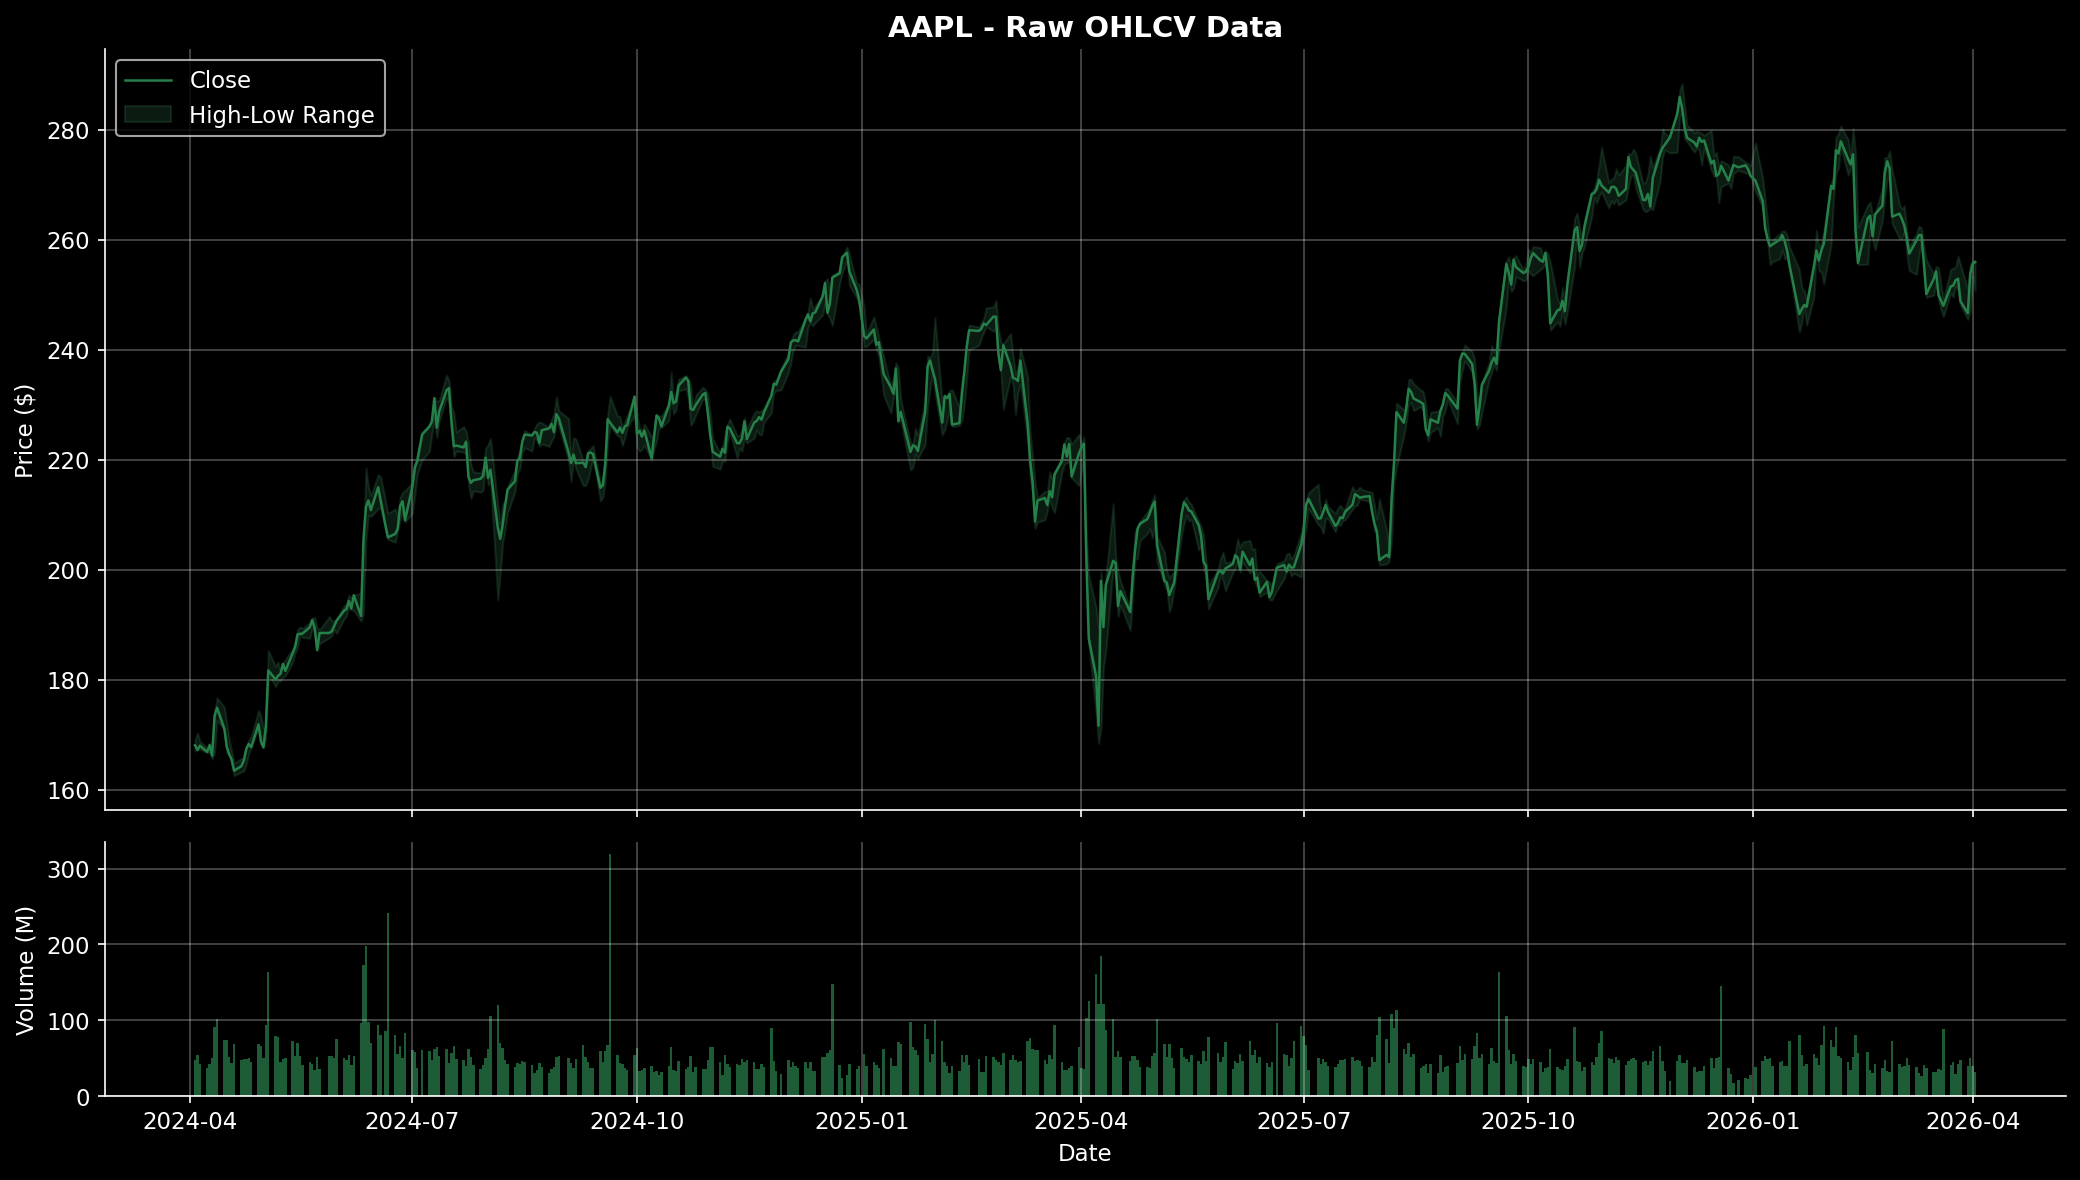

Summary Statistics:
  Price range: $163.51 - $285.92
  Avg daily volume: 53,899,223
  Total trading days: 502


In [3]:
# Visualize the raw OHLCV data
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

# Price chart
axes[0].plot(df.index, df['Close'], color=COLORS['primary'], linewidth=1.2, label='Close')
axes[0].fill_between(df.index, df['Low'], df['High'], alpha=0.15, color=COLORS['accent'],
                      label='High-Low Range')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('AAPL - Raw OHLCV Data', fontweight='bold', fontsize=14)
axes[0].legend(loc='upper left', framealpha=0.8)

# Volume chart
axes[1].bar(df.index, df['Volume'] / 1e6, color=COLORS['secondary'], alpha=0.6, width=1)
axes[1].set_ylabel('Volume (M)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

# Summary statistics
print('Summary Statistics:')
print(f'  Price range: ${df["Close"].min():.2f} - ${df["Close"].max():.2f}')
print(f'  Avg daily volume: {df["Volume"].mean():,.0f}')
print(f'  Total trading days: {len(df)}')

## 3. Return Computation and Volatility Estimation

Raw prices are not directly useful for quantitative models. Prices of different stocks have different scales - a stock at $50 and a stock at $500 cannot be compared directly. We need **returns**: the percentage change from one period to the next.

### 3.1 Simple Returns

The simple (arithmetic) return measures the actual percentage change:

$$R_t = \frac{C_t - C_{t-1}}{C_{t-1}} = \frac{C_t}{C_{t-1}} - 1$$

Simple returns are **additive across assets** - the portfolio return is a weighted sum:

$$R_p = \sum_i w_i R_i$$

This makes them the natural choice for portfolio analysis and performance attribution.

### 3.2 Log Returns

The logarithmic (continuously compounded) return is:

$$r_t = \ln\left(\frac{C_t}{C_{t-1}}\right) = \ln(C_t) - \ln(C_{t-1})$$

Log returns are **additive over time**:

$$r_{t_1 \to t_3} = r_{t_1 \to t_2} + r_{t_2 \to t_3}$$

This makes them natural for time series modeling, volatility estimation, and any analysis that involves temporal aggregation.

**Rule of thumb:** Use log returns for single-asset time series analysis. Use simple returns for cross-sectional portfolio work.

### 3.3 Realized Volatility

Volatility is the most important risk measure in quantitative finance. The **realized volatility** from daily log returns over a window of $N$ days is:

$$\hat{\sigma} = \sqrt{\frac{1}{N-1} \sum_{t=1}^{N} (r_t - \bar{r})^2}$$

To **annualize** daily volatility:

$$\sigma_{\text{annual}} = \hat{\sigma}_{\text{daily}} \times \sqrt{252}$$

where 252 is the typical number of trading days per year.

In [4]:
def compute_returns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add simple returns, log returns, and rolling volatility to a DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with 'Close' column
    
    Returns
    -------
    pd.DataFrame
        DataFrame with added columns: simple_return, log_return, realized_vol_20d
    """
    result = df.copy()
    
    # Simple returns
    result['simple_return'] = result['Close'].pct_change()
    
    # Log returns
    result['log_return'] = np.log(result['Close'] / result['Close'].shift(1))
    
    # 20-day rolling annualized volatility
    result['realized_vol_20d'] = (
        result['log_return'].rolling(window=20).std() * np.sqrt(252)
    )
    
    # 60-day rolling annualized volatility (for comparison)
    result['realized_vol_60d'] = (
        result['log_return'].rolling(window=60).std() * np.sqrt(252)
    )
    
    return result


# Compute returns for AAPL
df = compute_returns(df)

print('Return Statistics (AAPL):')
print(f'  Mean daily simple return: {df["simple_return"].mean():.4%}')
print(f'  Mean daily log return:    {df["log_return"].mean():.4%}')
print(f'  Daily return std dev:     {df["log_return"].std():.4%}')
print(f'  Annualized volatility:    {df["log_return"].std() * np.sqrt(252):.2%}')
print(f'  Max daily gain:           {df["simple_return"].max():.2%}')
print(f'  Max daily loss:           {df["simple_return"].min():.2%}')
print(f'  Skewness:                 {df["log_return"].skew():.3f}')
print(f'  Excess Kurtosis:          {df["log_return"].kurtosis():.3f}')

Return Statistics (AAPL):
  Mean daily simple return: 0.0997%
  Mean daily log return:    0.0839%
  Daily return std dev:     1.7744%
  Annualized volatility:    28.17%
  Max daily gain:           15.33%
  Max daily loss:           -9.25%
  Skewness:                 0.578
  Excess Kurtosis:          10.979


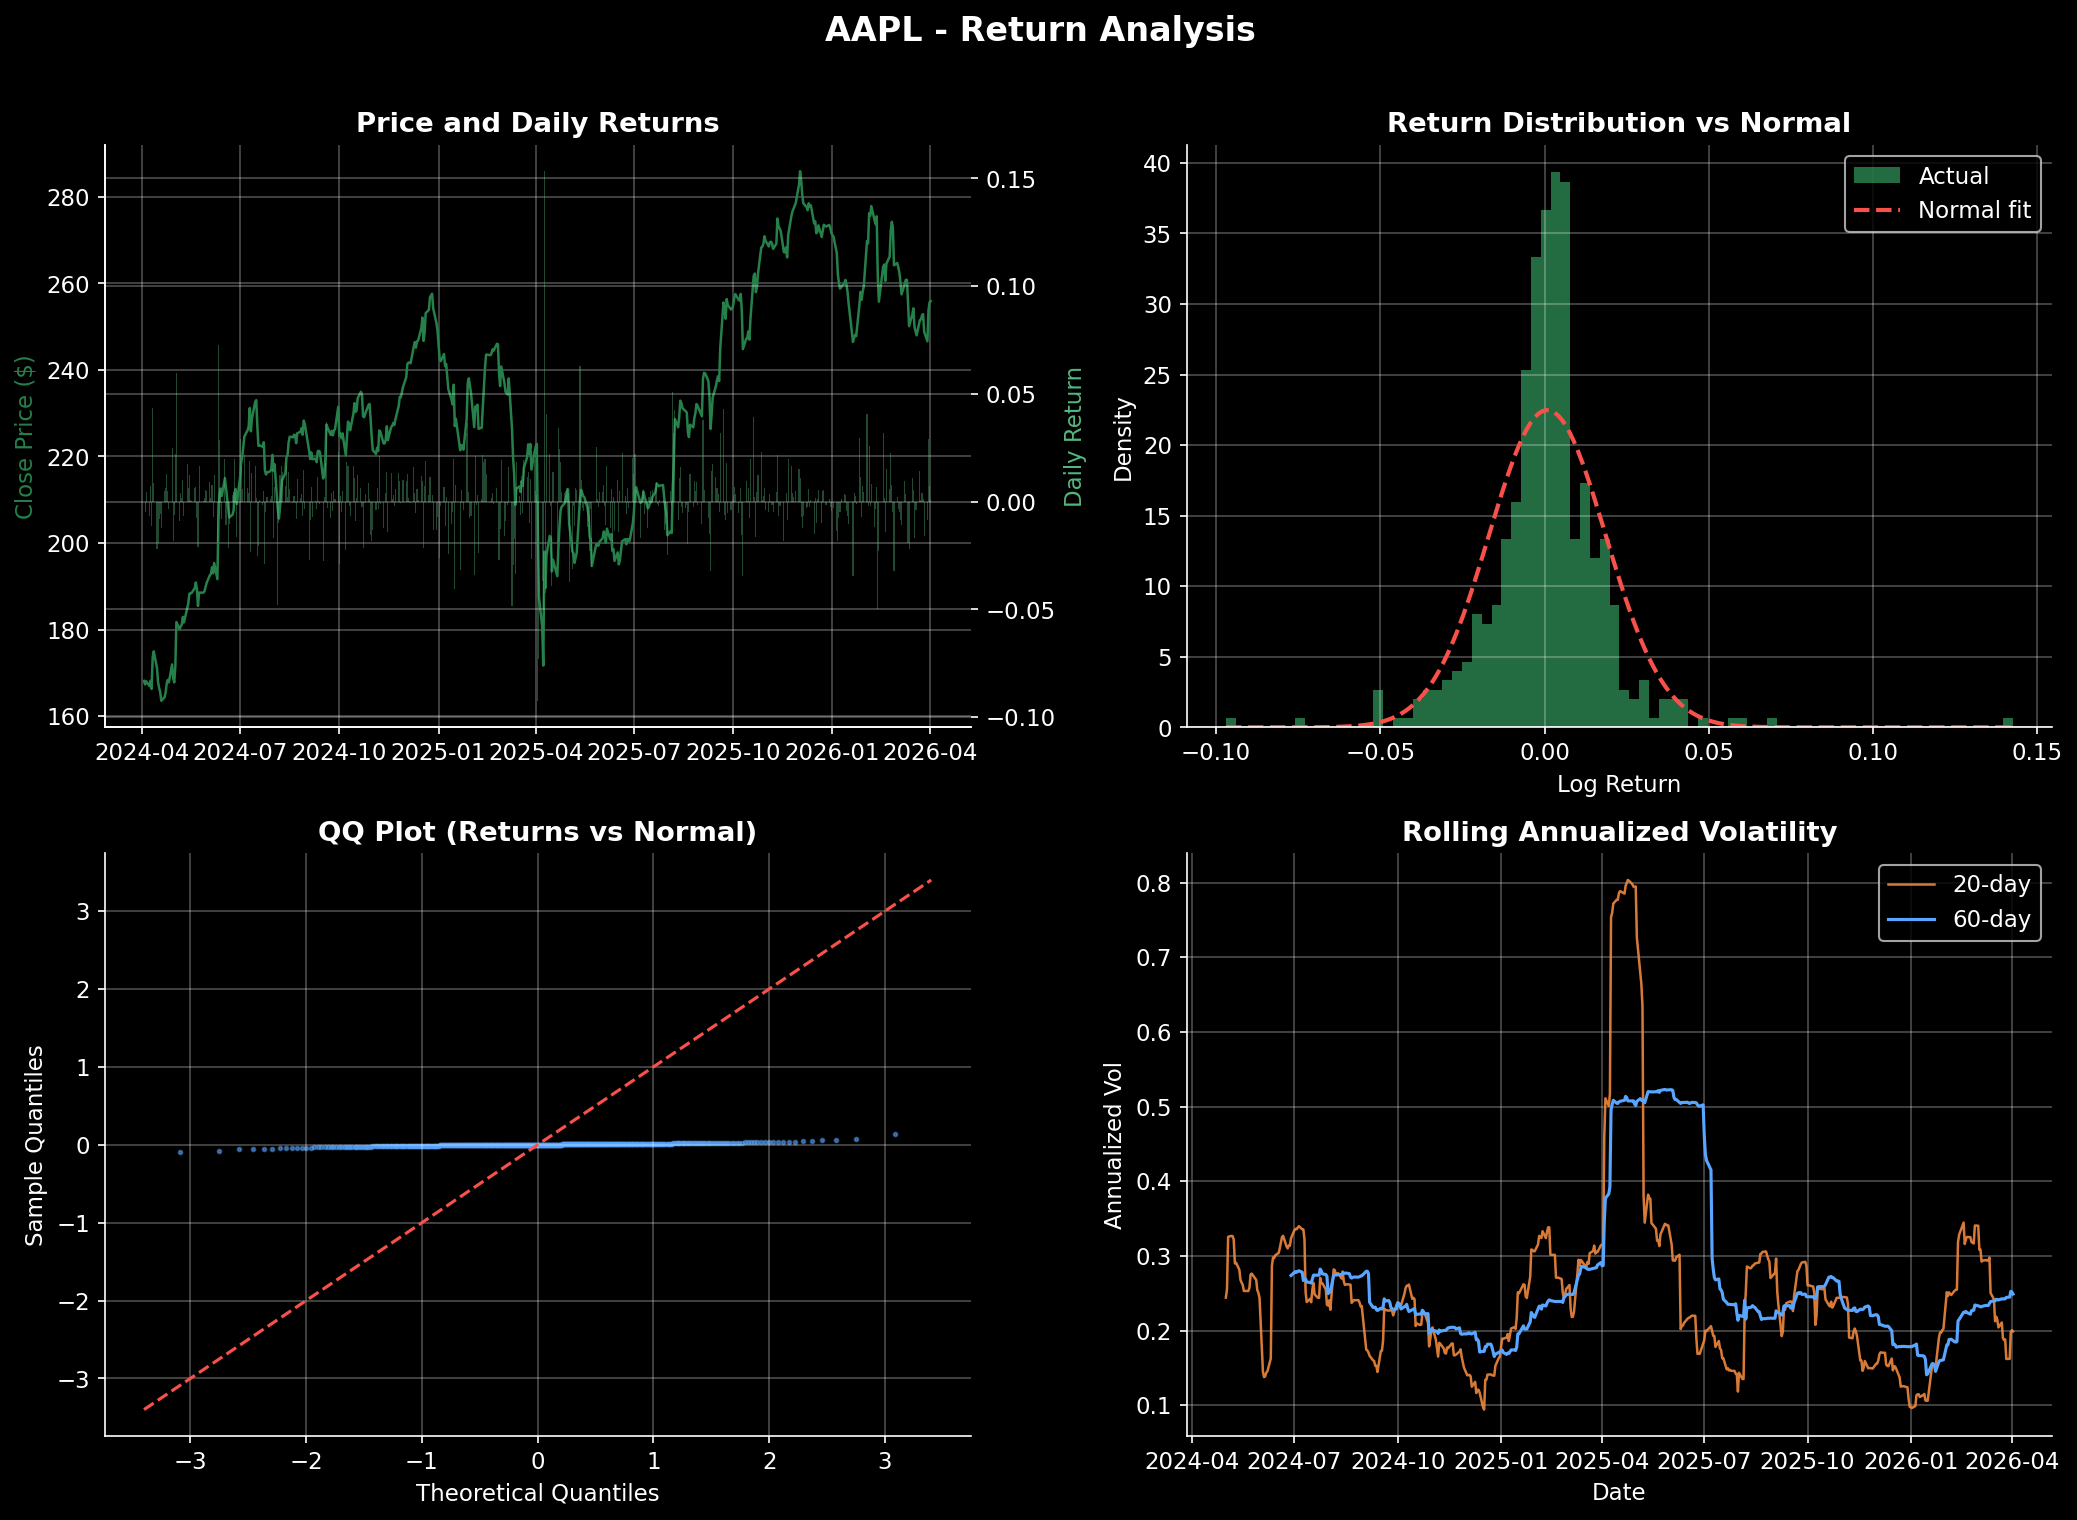


Fat tails evidence:
  Excess kurtosis: 10.98 (normal = 0)
  This means extreme events are ~3.7x more likely than a normal distribution predicts.
  Days with |return| > 3 std: 6
  Expected under normal: ~1.4


In [5]:
# Comprehensive return visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

returns = df['log_return'].dropna()

# 1. Price and returns
ax1_twin = axes[0, 0].twinx()
axes[0, 0].plot(df.index, df['Close'], color=COLORS['primary'], linewidth=1.2)
axes[0, 0].set_ylabel('Close Price ($)', color=COLORS['primary'])
ax1_twin.bar(df.index, df['simple_return'], color=COLORS['accent'], alpha=0.4, width=1)
ax1_twin.set_ylabel('Daily Return', color=COLORS['accent'])
axes[0, 0].set_title('Price and Daily Returns', fontweight='bold')

# 2. Return distribution vs Normal
axes[0, 1].hist(returns, bins=80, density=True, alpha=0.7, color=COLORS['secondary'],
                edgecolor='none', label='Actual')
x_range = np.linspace(returns.min(), returns.max(), 200)
normal_pdf = stats.norm.pdf(x_range, returns.mean(), returns.std())
axes[0, 1].plot(x_range, normal_pdf, color=COLORS['red'], linewidth=2, linestyle='--',
                label='Normal fit')
axes[0, 1].set_title('Return Distribution vs Normal', fontweight='bold')
axes[0, 1].set_xlabel('Log Return')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# 3. QQ plot
theoretical = np.sort(stats.norm.ppf(np.linspace(0.001, 0.999, len(returns))))
empirical = np.sort(returns.values)
axes[1, 0].scatter(theoretical, empirical, s=3, alpha=0.5, color=COLORS['blue'])
lim = max(abs(theoretical.min()), abs(theoretical.max())) * 1.1
axes[1, 0].plot([-lim, lim], [-lim, lim], color=COLORS['red'], linewidth=1.5, linestyle='--')
axes[1, 0].set_title('QQ Plot (Returns vs Normal)', fontweight='bold')
axes[1, 0].set_xlabel('Theoretical Quantiles')
axes[1, 0].set_ylabel('Sample Quantiles')

# 4. Rolling volatility
axes[1, 1].plot(df.index, df['realized_vol_20d'], color=COLORS['orange'],
                linewidth=1.2, label='20-day', alpha=0.9)
axes[1, 1].plot(df.index, df['realized_vol_60d'], color=COLORS['blue'],
                linewidth=1.5, label='60-day')
axes[1, 1].set_title('Rolling Annualized Volatility', fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Annualized Vol')
axes[1, 1].legend()

plt.suptitle('AAPL - Return Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Fat tails evidence
kurt = returns.kurtosis()
print(f'\nFat tails evidence:')
print(f'  Excess kurtosis: {kurt:.2f} (normal = 0)')
print(f'  This means extreme events are ~{kurt/3:.1f}x more likely than a normal distribution predicts.')
print(f'  Days with |return| > 3 std: {(returns.abs() > 3 * returns.std()).sum()}')
print(f'  Expected under normal: ~{len(returns) * 0.0027:.1f}')

The QQ plot is the clearest diagnostic. If returns were normally distributed, the points would lie exactly on the red diagonal. The systematic departure in the tails shows that extreme positive and negative returns occur far more often than a Gaussian model predicts. This is why naive z-score-based outlier detection fails for financial data - we address this in Section 6.

## 4. OHLCV Structural Validation

The first layer of any data pipeline is structural validation: checking that the data satisfies basic physical constraints. For OHLCV data:

1. $L_t \leq O_t$ - Low cannot exceed Open
2. $L_t \leq C_t$ - Low cannot exceed Close
3. $O_t \leq H_t$ - Open cannot exceed High
4. $C_t \leq H_t$ - Close cannot exceed High
5. $V_t \geq 0$ - Volume cannot be negative

These checks catch corrupted data, vendor errors, and transmission glitches before they propagate into downstream models.

In [6]:
def validate_ohlcv(df: pd.DataFrame) -> Dict:
    """
    Validate OHLCV structural constraints.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with Open, High, Low, Close, Volume columns
    
    Returns
    -------
    dict
        Validation results with 'valid', 'n_violations', and 'violations' breakdown
    """
    violations = {
        'low_gt_open': int((df['Low'] > df['Open']).sum()),
        'low_gt_close': int((df['Low'] > df['Close']).sum()),
        'open_gt_high': int((df['Open'] > df['High']).sum()),
        'close_gt_high': int((df['Close'] > df['High']).sum()),
        'negative_volume': int((df['Volume'] < 0).sum()),
        'null_close': int(df['Close'].isna().sum()),
        'null_volume': int(df['Volume'].isna().sum()),
        'zero_close': int((df['Close'] == 0).sum()),
    }
    
    n_violations = sum(violations.values())
    
    return {
        'valid': n_violations == 0,
        'n_violations': n_violations,
        'n_rows': len(df),
        'violations': violations,
    }


# Validate all tickers
print('OHLCV Structural Validation')
print('=' * 50)

for ticker in tickers:
    result = validate_ohlcv(data[ticker])
    status = 'PASS' if result['valid'] else 'FAIL'
    print(f'{ticker}: {status} ({result["n_rows"]} rows, {result["n_violations"]} violations)')
    if not result['valid']:
        for check, count in result['violations'].items():
            if count > 0:
                print(f'  - {check}: {count}')

OHLCV Structural Validation
AAPL: PASS (502 rows, 0 violations)
MSFT: PASS (502 rows, 0 violations)
TSLA: PASS (502 rows, 0 violations)
GOOG: PASS (502 rows, 0 violations)


In [7]:
# Demonstrate with intentionally corrupted data
corrupted = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Inject errors
np.random.seed(42)
n = len(corrupted)

# Swap some Low and High values (simulating vendor error)
swap_idx = corrupted.index[np.random.choice(n, 3, replace=False)]
for idx in swap_idx:
    corrupted.loc[idx, 'Low'], corrupted.loc[idx, 'High'] = (
        corrupted.loc[idx, 'High'], corrupted.loc[idx, 'Low']
    )

# Inject a negative volume
corrupted.iloc[50, 4] = -1000

# Validate
result = validate_ohlcv(corrupted)
print('Corrupted Data Validation:')
print(f'  Valid: {result["valid"]}')
print(f'  Total violations: {result["n_violations"]}')
for check, count in result['violations'].items():
    if count > 0:
        print(f'  - {check}: {count}')

# Show the corrupted rows
print('\nCorrupted rows:')
for idx in swap_idx:
    row = corrupted.loc[idx]
    print(f'  {idx.strftime("%Y-%m-%d")}: O={row["Open"]:.2f} H={row["High"]:.2f} '
          f'L={row["Low"]:.2f} C={row["Close"]:.2f}')

Corrupted Data Validation:
  Valid: False
  Total violations: 13
  - low_gt_open: 3
  - low_gt_close: 3
  - open_gt_high: 3
  - close_gt_high: 3
  - negative_volume: 1

Corrupted rows:
  2025-04-29: O=207.78 H=207.47 L=211.32 C=210.29
  2024-07-18: O=228.51 H=220.56 L=228.67 C=222.46
  2025-05-29: O=202.96 H=197.91 L=203.19 C=199.34


## 5. Missing Data Detection and Gap Filling

### 5.1 The Trading Calendar Problem

Markets don't operate every day. The NYSE is closed on weekends, federal holidays, and occasionally for extraordinary events. Your data will naturally have no entries for these days. The challenge is distinguishing **legitimate closures** from **data feed failures**.

| Gap Type | Calendar Days | Action |
|----------|---------------|--------|
| Normal weekday | 1 | Expected |
| Weekend | 3 (Fri to Mon) | Expected |
| Holiday weekend | 4 | Usually legitimate |
| 5+ days | Suspicious | Investigate |

### 5.2 Survivorship Bias

One of the most dangerous forms of missing data is **survivorship bias**: datasets that only contain stocks that currently exist. Companies that went bankrupt, were acquired, or were delisted simply disappear from the dataset.

Academic studies estimate survivorship bias inflates average annual returns of U.S. equity portfolios by **0.5% to 1.5% per year**. Over a 10-year backtest, that can be the difference between a profitable strategy and a money-losing one.

### 5.3 Fill Strategies

- **Prices**: Forward-fill (last known price is the best estimate)
- **Volume**: Fill with zero (no trades occurred during the gap)
- **Returns**: Implied zero (price didn't change during forward-fill)

**Never** interpolate prices linearly between the gap endpoints - this introduces look-ahead bias by using the post-gap price.

In [8]:
def detect_gaps(dates: pd.DatetimeIndex, threshold: int = 5) -> List[Dict]:
    """
    Detect gaps in a date index that exceed a threshold.
    
    Parameters
    ----------
    dates : pd.DatetimeIndex
        Trading dates
    threshold : int
        Minimum calendar days to flag as a gap (default: 5)
    
    Returns
    -------
    list of dict
        Each dict has 'start', 'end', 'calendar_days', 'business_days'
    """
    gaps = []
    day_diffs = pd.Series(dates[1:]) - pd.Series(dates[:-1])
    calendar_days = day_diffs.dt.days
    
    for i in range(len(calendar_days)):
        if calendar_days.iloc[i] >= threshold:
            start = dates[i]
            end = dates[i + 1]
            bdays = len(pd.bdate_range(start, end)) - 2  # Exclude endpoints
            gaps.append({
                'start': start,
                'end': end,
                'calendar_days': int(calendar_days.iloc[i]),
                'business_days_missing': bdays,
            })
    
    return gaps


def forward_fill_prices(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
    """
    Forward-fill missing prices and zero-fill volume.
    Returns the filled DataFrame and a fill report.
    
    Parameters
    ----------
    df : pd.DataFrame
        OHLCV DataFrame (may contain NaN)
    
    Returns
    -------
    tuple of (pd.DataFrame, dict)
        Filled DataFrame and fill report
    """
    report = {}
    result = df.copy()
    
    # Count missing before filling
    price_cols = ['Open', 'High', 'Low', 'Close']
    for col in price_cols:
        if col in result.columns:
            n_missing = int(result[col].isna().sum())
            if n_missing > 0:
                report[col] = n_missing
            result[col] = result[col].ffill()
    
    if 'Volume' in result.columns:
        n_missing = int(result['Volume'].isna().sum())
        if n_missing > 0:
            report['Volume'] = n_missing
        result['Volume'] = result['Volume'].fillna(0)
    
    report['total_filled'] = sum(report.values())
    
    return result, report


# Detect gaps in AAPL
gaps = detect_gaps(df.index, threshold=5)
print(f'AAPL: Found {len(gaps)} gaps larger than a normal weekend:')
for gap in gaps:
    print(f'  {gap["start"].strftime("%Y-%m-%d")} to {gap["end"].strftime("%Y-%m-%d")} '
          f'({gap["calendar_days"]} calendar days, '
          f'{gap["business_days_missing"]} business days missing)')

AAPL: Found 0 gaps larger than a normal weekend:


Total business days in range: 522
Days with data: 502
Missing business days: 20 (mostly holidays)

Fill report: {'Open': 20, 'High': 20, 'Low': 20, 'Close': 20, 'Volume': 20, 'total_filled': 100}


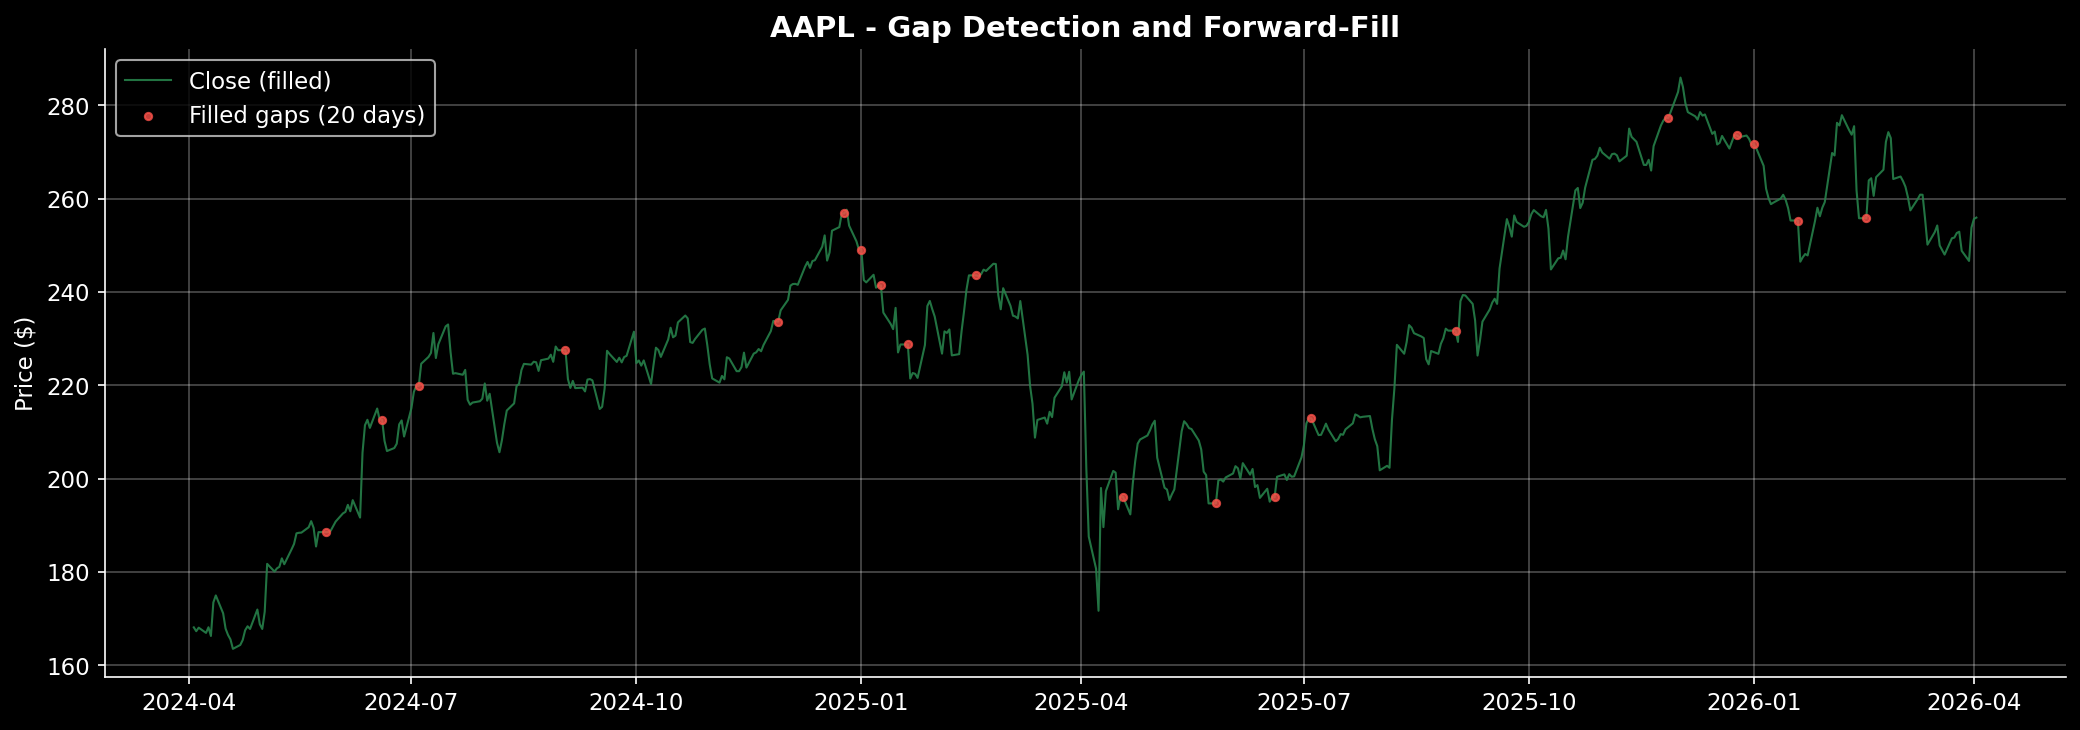


Gap dates (likely holidays):
  2024-05-27 (Monday)
  2024-06-19 (Wednesday)
  2024-07-04 (Thursday)
  2024-09-02 (Monday)
  2024-11-28 (Thursday)
  2024-12-25 (Wednesday)
  2025-01-01 (Wednesday)
  2025-01-09 (Thursday)
  2025-01-20 (Monday)
  2025-02-17 (Monday)
  2025-04-18 (Friday)
  2025-05-26 (Monday)
  2025-06-19 (Thursday)
  2025-07-04 (Friday)
  2025-09-01 (Monday)
  ... and 5 more


In [9]:
# Reindex to full business day calendar to visualize all gaps
full_index = pd.bdate_range(df.index[0], df.index[-1])
df_reindexed = df[['Open', 'High', 'Low', 'Close', 'Volume']].reindex(full_index)

missing_dates = df_reindexed[df_reindexed['Close'].isna()]
print(f'Total business days in range: {len(full_index)}')
print(f'Days with data: {len(df)}')
print(f'Missing business days: {len(missing_dates)} (mostly holidays)')

# Forward-fill
df_filled, fill_report = forward_fill_prices(df_reindexed)
print(f'\nFill report: {fill_report}')

# Visualize gaps
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_filled.index, df_filled['Close'], color=COLORS['primary'],
        linewidth=1.0, label='Close (filled)', alpha=0.9)

if len(missing_dates) > 0:
    filled_prices = df_filled.loc[missing_dates.index, 'Close']
    ax.scatter(missing_dates.index, filled_prices, color=COLORS['red'],
              s=12, zorder=5, label=f'Filled gaps ({len(missing_dates)} days)', alpha=0.8)

ax.set_ylabel('Price ($)')
ax.set_title('AAPL - Gap Detection and Forward-Fill', fontweight='bold', fontsize=14)
ax.legend(loc='upper left', framealpha=0.8)

plt.tight_layout()
plt.show()

print('\nGap dates (likely holidays):')
for date in missing_dates.index[:15]:
    print(f'  {date.strftime("%Y-%m-%d")} ({date.strftime("%A")})')
if len(missing_dates) > 15:
    print(f'  ... and {len(missing_dates) - 15} more')

## 6. Outlier Detection for Fat-Tailed Data

### 6.1 Why Z-Scores Fail

The standard approach to outlier detection is the z-score:

$$z_t = \frac{r_t - \mu}{\sigma}$$

Flag any point where $|z| > 3$. This works for normally distributed data. Financial returns are **not** normally distributed - they have **fat tails** (excess kurtosis).

Two problems with z-scores on fat-tailed data:
1. **Too many false positives**: Legitimate extreme moves get flagged
2. **Masking effect**: A single extreme value inflates $\sigma$, making all z-scores (including the outlier's) appear smaller

### 6.2 Median Absolute Deviation (MAD)

The **MAD** is a robust measure of spread:

$$\text{MAD} = \text{median}\left(|r_t - \tilde{r}|\right)$$

where $\tilde{r}$ is the median. Because it uses medians instead of means, a single extreme value cannot distort it.

To make MAD comparable to the standard deviation for normally distributed data, scale by 1.4826:

$$\hat{\sigma}_{\text{MAD}} = 1.4826 \times \text{MAD}$$

The **modified z-score** is:

$$M_t = \frac{r_t - \tilde{r}}{1.4826 \times \text{MAD}}$$

A threshold of $|M_t| > 3.5$ is standard.

### 6.3 Rolling Windows

Financial volatility is **not stationary** - it changes over time. A 2% daily move is unremarkable during a crisis but extreme during a calm period. We use **rolling windows** (typically 63 trading days, about 3 months) so the outlier threshold adapts to the current volatility regime.

In [10]:
def compute_mad(series: pd.Series) -> float:
    """Compute the Median Absolute Deviation of a series."""
    median_val = series.median()
    return (series - median_val).abs().median()


def modified_z_scores(series: pd.Series) -> pd.Series:
    """Compute modified z-scores using MAD."""
    median_val = series.median()
    mad = compute_mad(series)
    scaled_mad = 1.4826 * mad
    if scaled_mad == 0:
        return pd.Series(0.0, index=series.index)
    return (series - median_val) / scaled_mad


def detect_outliers_mad(
    returns: pd.Series,
    window: int = 63,
    threshold: float = 3.5,
    min_periods: int = 20,
) -> Dict:
    """
    Detect outliers using rolling MAD-based modified z-scores.
    
    Parameters
    ----------
    returns : pd.Series
        Return series
    window : int
        Rolling window size (default: 63, about 3 months)
    threshold : float
        Modified z-score threshold (default: 3.5)
    min_periods : int
        Minimum observations for rolling calculation
    
    Returns
    -------
    dict
        'modified_z', 'is_outlier' (Series), 'n_outliers' (int), 'outlier_dates' (DatetimeIndex)
    """
    # Rolling median and MAD
    rolling_median = returns.rolling(window=window, min_periods=min_periods).median()
    deviations = (returns - rolling_median).abs()
    rolling_mad = deviations.rolling(window=window, min_periods=min_periods).median()
    scaled_mad = 1.4826 * rolling_mad
    
    # Modified z-scores
    mod_z = (returns - rolling_median) / scaled_mad
    is_outlier = mod_z.abs() > threshold
    
    return {
        'modified_z': mod_z,
        'is_outlier': is_outlier,
        'n_outliers': int(is_outlier.sum()),
        'outlier_dates': returns.index[is_outlier],
    }


# Demonstrate MAD robustness
clean = pd.Series([1.0, 2.0, 3.0, 4.0, 5.0])
contaminated = pd.Series([1.0, 2.0, 3.0, 4.0, 100.0])

print('MAD Robustness Demonstration')
print('=' * 50)
print(f'Clean data [1,2,3,4,5]:')
print(f'  Std dev = {clean.std():.3f},  MAD = {compute_mad(clean):.3f}')
print(f'Contaminated [1,2,3,4,100]:')
print(f'  Std dev = {contaminated.std():.3f},  MAD = {compute_mad(contaminated):.3f}')
print(f'\nStd dev inflated by {contaminated.std() / clean.std():.1f}x')
print(f'MAD changed by {compute_mad(contaminated) / compute_mad(clean):.1f}x')
print(f'\nThis is why MAD is essential for fat-tailed financial data.')

MAD Robustness Demonstration
Clean data [1,2,3,4,5]:
  Std dev = 1.581,  MAD = 1.000
Contaminated [1,2,3,4,100]:
  Std dev = 43.618,  MAD = 1.000

Std dev inflated by 27.6x
MAD changed by 1.0x

This is why MAD is essential for fat-tailed financial data.


In [11]:
# Compare z-score vs MAD outlier detection on real data
returns = df['log_return'].dropna()

# Standard z-scores (global mean and std)
z_scores_global = (returns - returns.mean()) / returns.std()
z_outliers = z_scores_global.abs() > 3

# MAD-based rolling detection
mad_result = detect_outliers_mad(returns, window=63, threshold=3.5)

print('Outlier Detection Comparison (AAPL)')
print('=' * 50)
print(f'Method 1 - Global z-score (threshold=3.0):')
print(f'  Outliers flagged: {z_outliers.sum()}')
print(f'Method 2 - Rolling MAD (window=63, threshold=3.5):')
print(f'  Outliers flagged: {mad_result["n_outliers"]}')

if mad_result['n_outliers'] > 0:
    print(f'\nMAD-flagged dates:')
    for date in mad_result['outlier_dates']:
        ret = returns.loc[date]
        mz = mad_result['modified_z'].loc[date]
        print(f'  {date.strftime("%Y-%m-%d")}: return = {ret:+.2%}, mod-z = {mz:+.2f}')

Outlier Detection Comparison (AAPL)
Method 1 - Global z-score (threshold=3.0):
  Outliers flagged: 6
Method 2 - Rolling MAD (window=63, threshold=3.5):
  Outliers flagged: 24

MAD-flagged dates:
  2024-06-10: return = -1.93%, mod-z = -3.58
  2024-06-11: return = +7.01%, mod-z = +8.77
  2024-08-05: return = -4.94%, mod-z = -4.50
  2025-01-16: return = -4.12%, mod-z = -4.29
  2025-03-10: return = -4.97%, mod-z = -4.02
  2025-04-03: return = -9.70%, mod-z = -5.54
  2025-04-04: return = -7.57%, mod-z = -4.32
  2025-04-09: return = +14.26%, mod-z = +7.76
  2025-08-06: return = +4.97%, mod-z = +6.36
  2025-08-07: return = +3.13%, mod-z = +3.95
  2025-08-08: return = +4.15%, mod-z = +5.09
  2025-09-03: return = +3.74%, mod-z = +4.37
  2025-09-10: return = -3.28%, mod-z = -3.94
  2025-09-19: return = +3.15%, mod-z = +3.78
  2025-09-22: return = +4.22%, mod-z = +4.91
  2025-10-10: return = -3.51%, mod-z = -4.04
  2025-10-20: return = +3.87%, mod-z = +3.55
  2026-01-20: return = -3.52%, mod-z = 

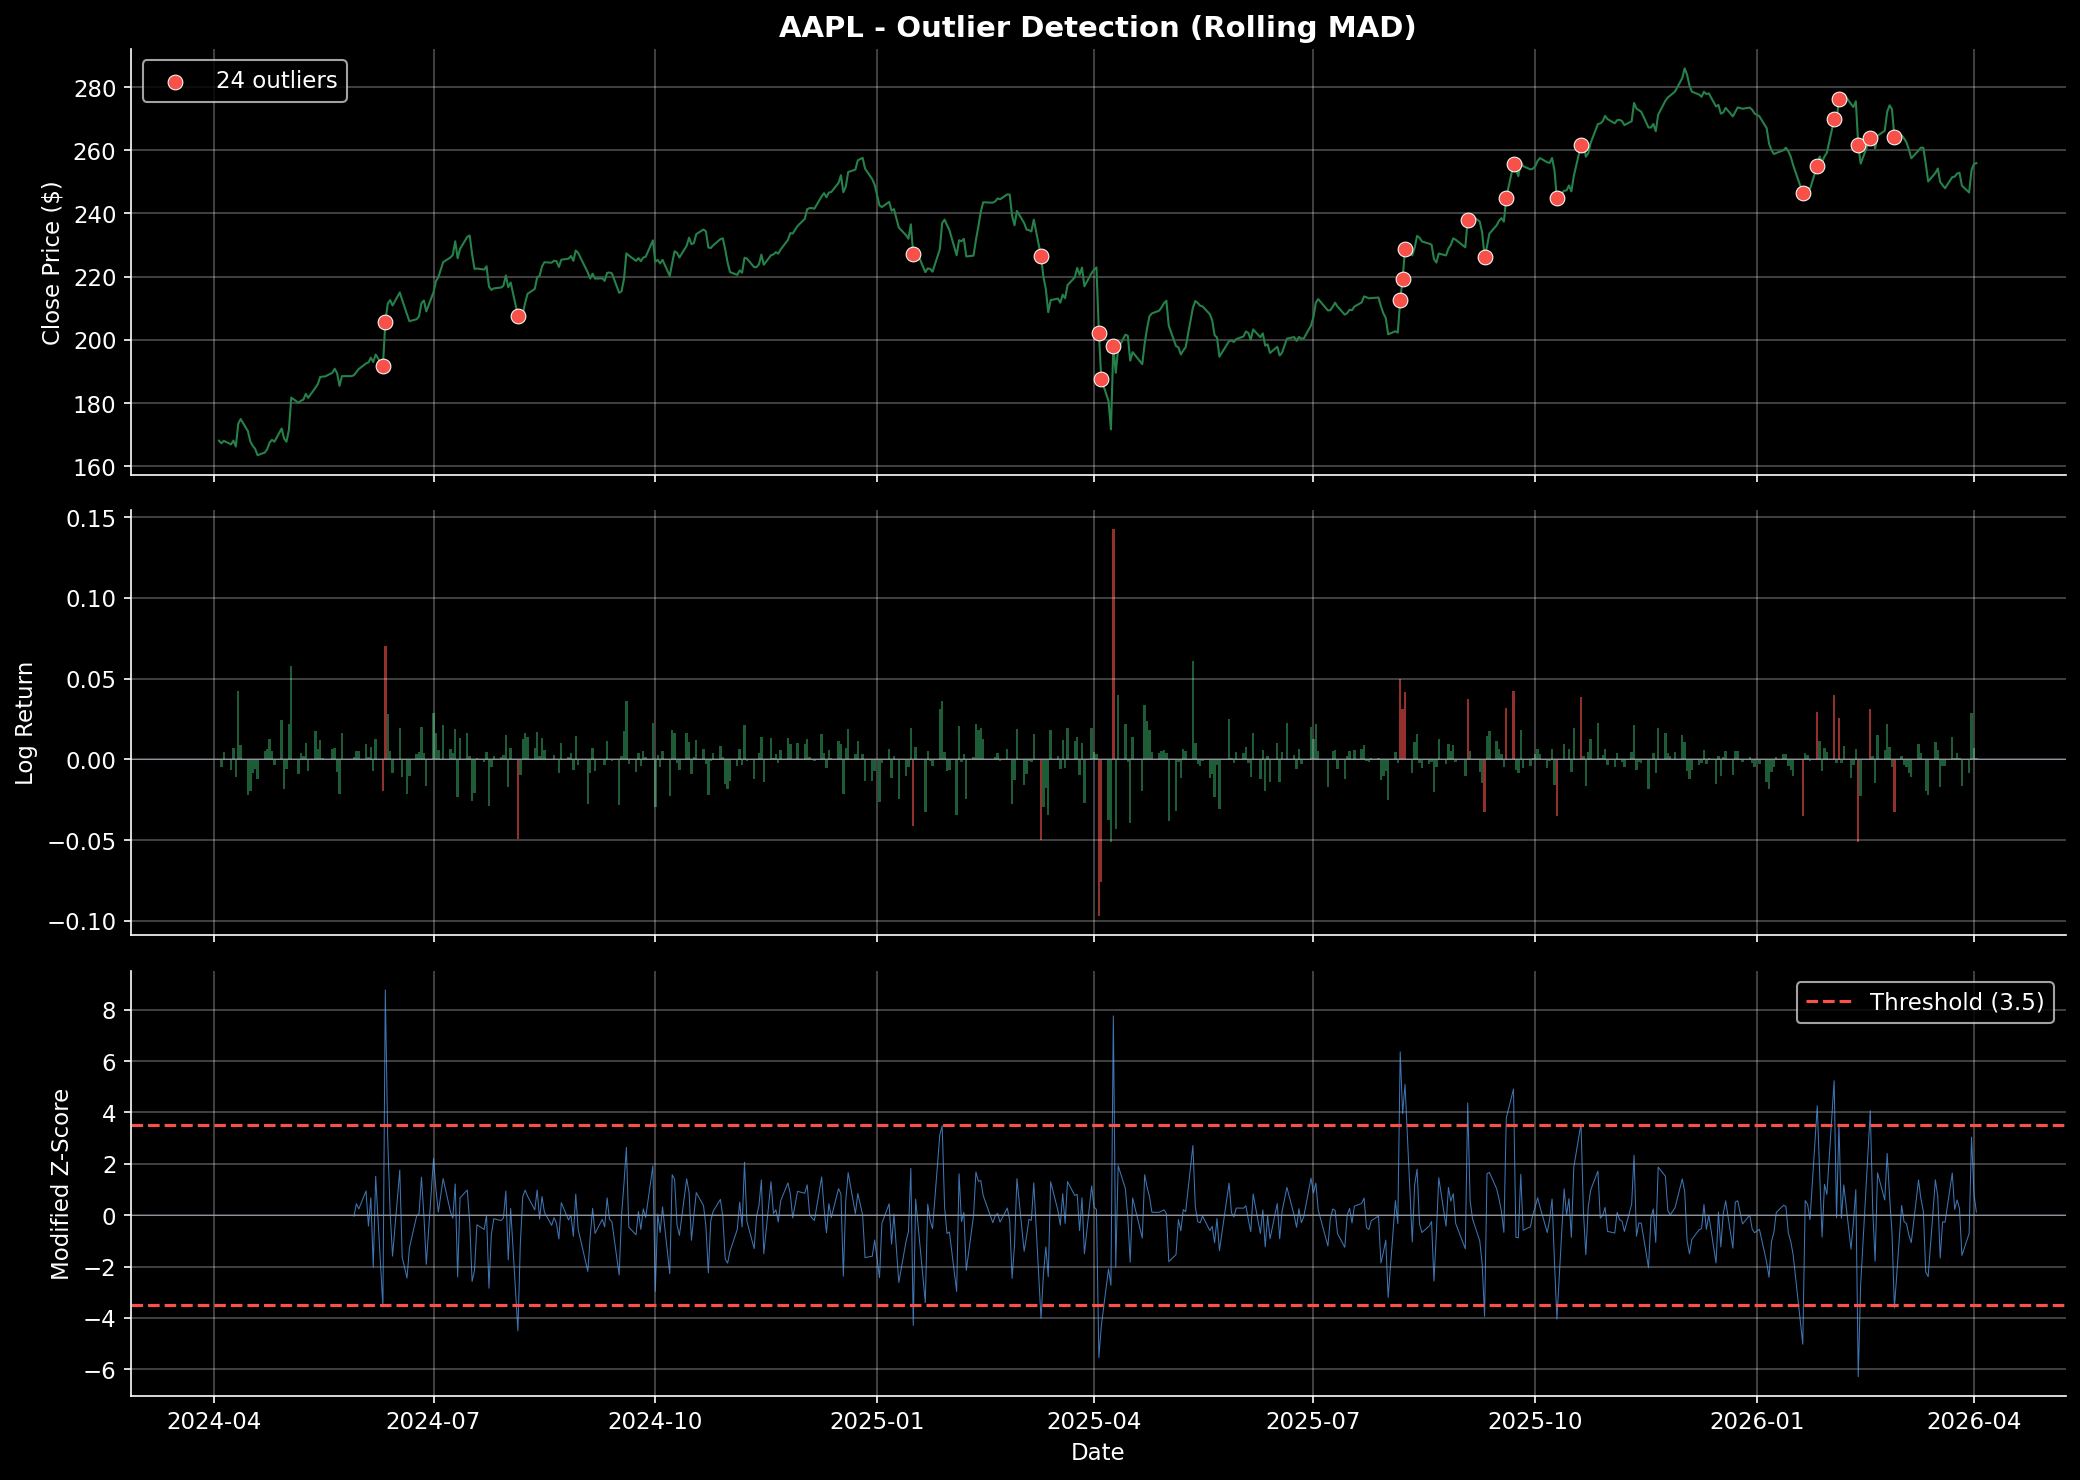

In [12]:
# Comprehensive outlier visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1. Price with outlier markers
axes[0].plot(df.index, df['Close'], color=COLORS['primary'], linewidth=1.0)
if mad_result['n_outliers'] > 0:
    outlier_prices = df.loc[mad_result['outlier_dates'], 'Close']
    axes[0].scatter(mad_result['outlier_dates'], outlier_prices,
                   color=COLORS['red'], s=50, zorder=5, edgecolors='white',
                   linewidth=0.5, label=f'{mad_result["n_outliers"]} outliers')
axes[0].set_ylabel('Close Price ($)')
axes[0].set_title('AAPL - Outlier Detection (Rolling MAD)', fontweight='bold', fontsize=14)
axes[0].legend()

# 2. Returns with outlier highlights
colors = [COLORS['red'] if mad_result['is_outlier'].get(d, False) else COLORS['secondary']
          for d in returns.index]
axes[1].bar(returns.index, returns, color=colors, alpha=0.6, width=1)
axes[1].set_ylabel('Log Return')
axes[1].axhline(y=0, color=COLORS['gray'], linewidth=0.5)

# 3. Modified z-scores with threshold bands
mz = mad_result['modified_z'].dropna()
axes[2].plot(mz.index, mz, color=COLORS['blue'], linewidth=0.5, alpha=0.7)
axes[2].axhline(y=3.5, color=COLORS['red'], linewidth=1.5, linestyle='--', label='Threshold (3.5)')
axes[2].axhline(y=-3.5, color=COLORS['red'], linewidth=1.5, linestyle='--')
axes[2].axhline(y=0, color=COLORS['gray'], linewidth=0.5)
axes[2].set_ylabel('Modified Z-Score')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Corporate Action Adjustments

### 7.1 The Problem with Raw Prices

When a stock undergoes a corporate action, the raw price changes discontinuously. These discontinuities are not real returns - they are accounting artifacts.

**Stock splits**: In a $k$:1 split, shares outstanding increase by factor $k$ and the price drops by factor $k$. The total market cap is unchanged.

For a split on date $t_s$, all historical prices before $t_s$ are divided by $k$, and volume is multiplied by $k$:

$$P_t^{\text{adj}} = \frac{P_t^{\text{raw}}}{k} \quad \text{for } t < t_s$$

$$V_t^{\text{adj}} = V_t^{\text{raw}} \times k \quad \text{for } t < t_s$$

**Cash dividends**: On the ex-date $t_d$, the price drops by approximately the dividend amount $D$. The adjustment factor is:

$$f_d = 1 - \frac{D}{C_{t_d - 1}}$$

All prices before $t_d$ are multiplied by this factor. Volume is not adjusted for dividends.

### 7.2 Direction of Adjustment

Adjustments are applied **backwards from today**. Today's price always equals the actual market price. Historical prices are adjusted downward. This means adjusted prices change every time a new corporate action occurs.

In [13]:
def adjust_for_splits(
    df: pd.DataFrame,
    splits: List[Dict],
) -> pd.DataFrame:
    """
    Adjust historical prices and volume for stock splits.
    
    Parameters
    ----------
    df : pd.DataFrame
        OHLCV DataFrame with DatetimeIndex
    splits : list of dict
        Each dict has 'date' (str) and 'ratio' (int)
    
    Returns
    -------
    pd.DataFrame
        Split-adjusted DataFrame
    """
    adjusted = df.copy()
    price_cols = ['Open', 'High', 'Low', 'Close']
    
    for split in splits:
        split_date = pd.Timestamp(split['date'])
        ratio = split['ratio']
        before = adjusted.index < split_date
        
        for col in price_cols:
            if col in adjusted.columns:
                adjusted.loc[before, col] = adjusted.loc[before, col] / ratio
        if 'Volume' in adjusted.columns:
            adjusted.loc[before, 'Volume'] = adjusted.loc[before, 'Volume'] * ratio
    
    return adjusted


def adjust_for_dividends(
    df: pd.DataFrame,
    dividends: List[Dict],
) -> pd.DataFrame:
    """
    Adjust historical prices for cash dividends.
    
    Parameters
    ----------
    df : pd.DataFrame
        OHLCV DataFrame with DatetimeIndex
    dividends : list of dict
        Each dict has 'ex_date' (str) and 'amount' (float)
    
    Returns
    -------
    pd.DataFrame
        Dividend-adjusted DataFrame
    """
    adjusted = df.copy()
    price_cols = ['Open', 'High', 'Low', 'Close']
    
    for div in dividends:
        ex_date = pd.Timestamp(div['ex_date'])
        amount = div['amount']
        before = adjusted.index < ex_date
        
        if not before.any():
            continue
        
        # Price the day before ex-date
        prior_close = adjusted.loc[before, 'Close'].iloc[-1]
        if prior_close <= 0:
            continue
        
        factor = 1 - amount / prior_close
        
        for col in price_cols:
            if col in adjusted.columns:
                adjusted.loc[before, col] = adjusted.loc[before, col] * factor
    
    return adjusted


print('Corporate action adjustment functions defined.')

Corporate action adjustment functions defined.


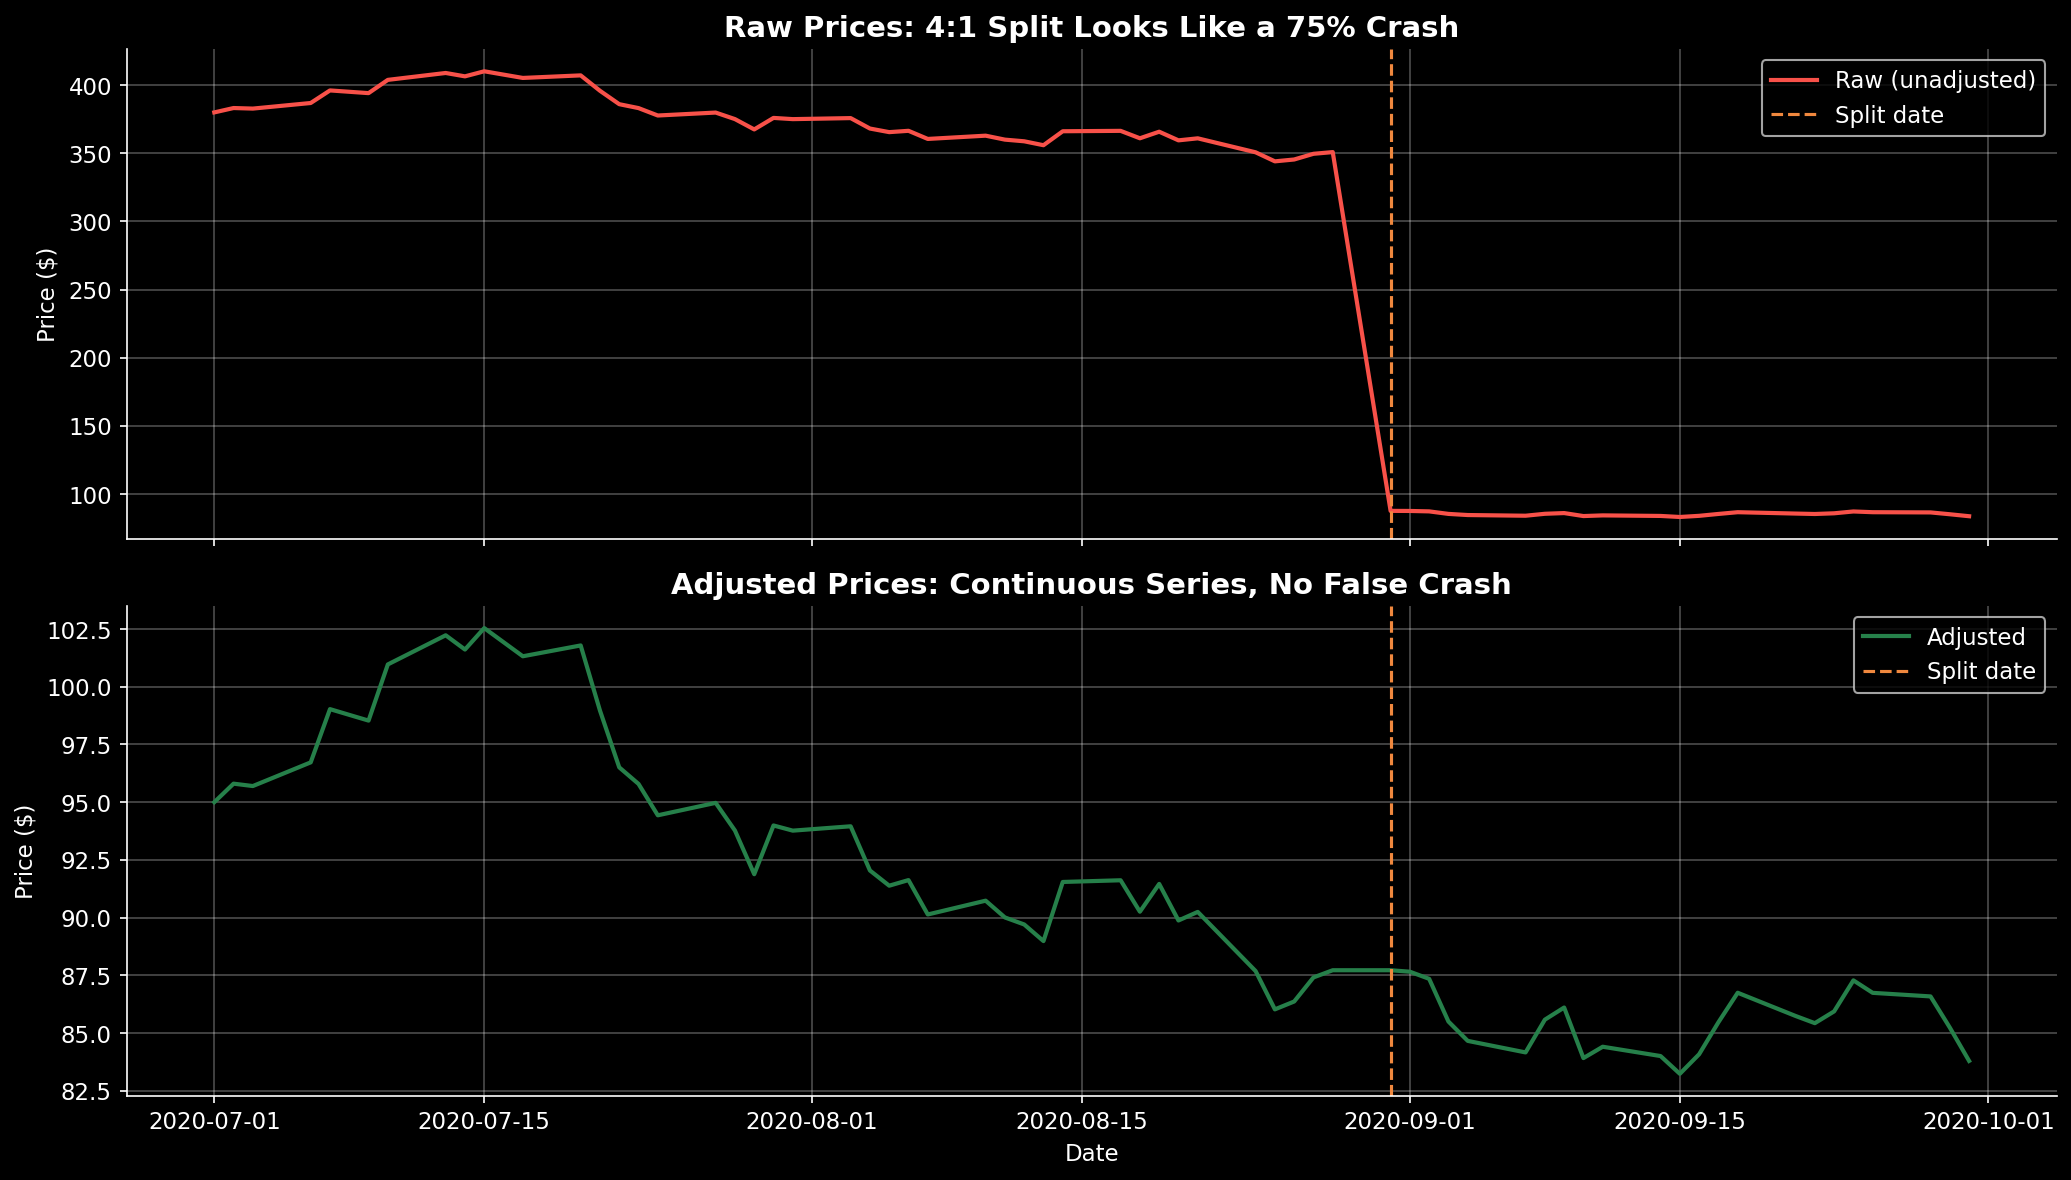


Return across split date:
  Raw: -75.00% (looks like a crash)
  Adjusted: 0.00% (reflects actual price change)


In [14]:
# Demonstrate split adjustment with synthetic data
# Simulating a 4:1 stock split (like AAPL Aug 2020)
np.random.seed(42)

dates = pd.bdate_range('2020-07-01', '2020-09-30')
n = len(dates)

# Generate raw prices: ~$400 pre-split, drops to ~$100 on split day
raw_prices = np.zeros(n)
raw_prices[0] = 380.0

split_idx = np.where(dates >= pd.Timestamp('2020-08-31'))[0][0]

# Pre-split price walk
for i in range(1, split_idx):
    raw_prices[i] = raw_prices[i-1] * (1 + np.random.normal(0.001, 0.015))

# Split occurs: price drops by factor of 4
raw_prices[split_idx] = raw_prices[split_idx - 1] / 4

# Post-split price walk
for i in range(split_idx + 1, n):
    raw_prices[i] = raw_prices[i-1] * (1 + np.random.normal(0.001, 0.015))

raw_volume = np.random.randint(30_000_000, 80_000_000, n)

df_split_demo = pd.DataFrame({
    'Open': raw_prices * (1 + np.random.uniform(-0.005, 0.005, n)),
    'High': raw_prices * (1 + np.random.uniform(0, 0.01, n)),
    'Low': raw_prices * (1 - np.random.uniform(0, 0.01, n)),
    'Close': raw_prices,
    'Volume': raw_volume,
}, index=dates)

# Adjust for the 4:1 split
splits = [{'date': '2020-08-31', 'ratio': 4}]
df_adjusted = adjust_for_splits(df_split_demo, splits)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_split_demo.index, df_split_demo['Close'], color=COLORS['red'],
            linewidth=2, label='Raw (unadjusted)')
axes[0].axvline(x=pd.Timestamp('2020-08-31'), color=COLORS['orange'],
               linestyle='--', linewidth=1.5, label='Split date')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Raw Prices: 4:1 Split Looks Like a 75% Crash', fontweight='bold', fontsize=14)
axes[0].legend()

axes[1].plot(df_adjusted.index, df_adjusted['Close'], color=COLORS['primary'],
            linewidth=2, label='Adjusted')
axes[1].axvline(x=pd.Timestamp('2020-08-31'), color=COLORS['orange'],
               linestyle='--', linewidth=1.5, label='Split date')
axes[1].set_ylabel('Price ($)')
axes[1].set_xlabel('Date')
axes[1].set_title('Adjusted Prices: Continuous Series, No False Crash', fontweight='bold', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

# Return comparison
raw_returns = df_split_demo['Close'].pct_change()
adj_returns = df_adjusted['Close'].pct_change()

print(f'\nReturn across split date:')
print(f'  Raw: {raw_returns.iloc[split_idx]:.2%} (looks like a crash)')
print(f'  Adjusted: {adj_returns.iloc[split_idx]:.2%} (reflects actual price change)')

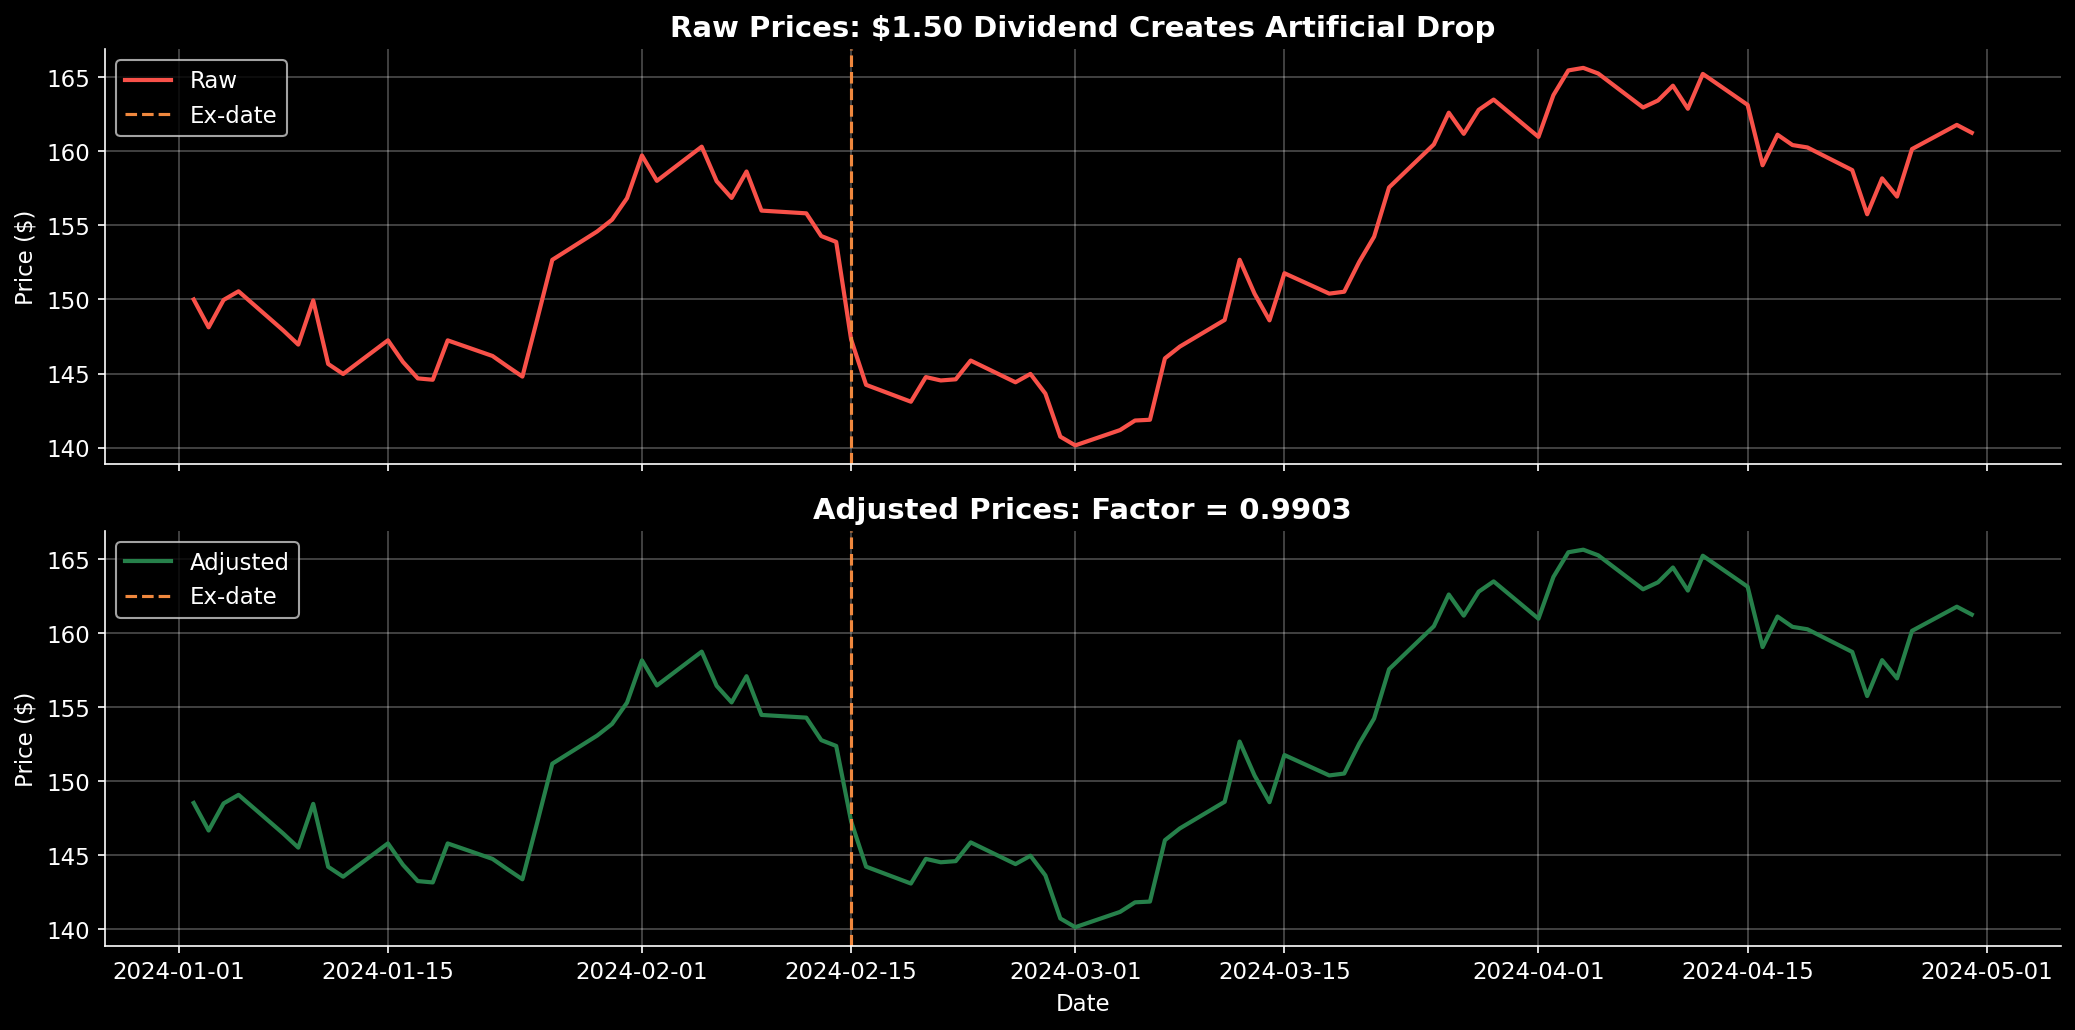


Dividend adjustment:
  Dividend: $1.50
  Prior close: $153.89
  Adjustment factor: 0.9903
  All pre-ex-date prices multiplied by 0.9903


In [15]:
# Demonstrate dividend adjustment with synthetic data
np.random.seed(123)

div_dates = pd.bdate_range('2024-01-02', '2024-04-30')
n_div = len(div_dates)
div_prices = np.zeros(n_div)
div_prices[0] = 150.0

ex_date_idx = np.where(div_dates >= pd.Timestamp('2024-02-15'))[0][0]

for i in range(1, n_div):
    div_prices[i] = div_prices[i-1] * (1 + np.random.normal(0.0005, 0.012))
    # Simulate dividend drop on ex-date
    if i == ex_date_idx:
        div_prices[i] -= 1.50  # $1.50 dividend

df_div_demo = pd.DataFrame({
    'Open': div_prices * (1 + np.random.uniform(-0.003, 0.003, n_div)),
    'High': div_prices * (1 + np.random.uniform(0, 0.008, n_div)),
    'Low': div_prices * (1 - np.random.uniform(0, 0.008, n_div)),
    'Close': div_prices,
    'Volume': np.random.randint(5_000_000, 15_000_000, n_div),
}, index=div_dates)

# Adjust for the dividend
dividends = [{'ex_date': '2024-02-15', 'amount': 1.50}]
df_div_adjusted = adjust_for_dividends(df_div_demo, dividends)

# Compute adjustment factor for display
prior_close = df_div_demo.loc[df_div_demo.index < pd.Timestamp('2024-02-15'), 'Close'].iloc[-1]
factor = 1 - 1.50 / prior_close

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df_div_demo.index, df_div_demo['Close'], color=COLORS['red'],
            linewidth=2, label='Raw')
axes[0].axvline(x=pd.Timestamp('2024-02-15'), color=COLORS['orange'],
               linestyle='--', linewidth=1.5, label='Ex-date')
axes[0].set_ylabel('Price ($)')
axes[0].set_title(f'Raw Prices: $1.50 Dividend Creates Artificial Drop', fontweight='bold', fontsize=14)
axes[0].legend()

axes[1].plot(df_div_adjusted.index, df_div_adjusted['Close'], color=COLORS['primary'],
            linewidth=2, label='Adjusted')
axes[1].axvline(x=pd.Timestamp('2024-02-15'), color=COLORS['orange'],
               linestyle='--', linewidth=1.5, label='Ex-date')
axes[1].set_ylabel('Price ($)')
axes[1].set_xlabel('Date')
axes[1].set_title(f'Adjusted Prices: Factor = {factor:.4f}', fontweight='bold', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nDividend adjustment:')
print(f'  Dividend: $1.50')
print(f'  Prior close: ${prior_close:.2f}')
print(f'  Adjustment factor: {factor:.4f}')
print(f'  All pre-ex-date prices multiplied by {factor:.4f}')

## 8. Full Quality Pipeline

Now we combine all the individual layers into a single automated pipeline. The correct order of operations is critical:

1. **Structural validation** - catch impossible values
2. **Corporate action adjustment** - fix splits and dividends before anything else
3. **Gap filling** - handle missing data
4. **Return computation** - simple and log returns
5. **Outlier detection** - flag anomalous returns
6. **Quality scoring** - overall confidence rating

### 8.1 Quality Scoring

The quality score combines three dimensions:

$$Q = Q_{\text{validity}} \times Q_{\text{completeness}} \times Q_{\text{outlier}}$$

Where:
- **Validity**: fraction of rows passing structural checks
- **Completeness**: fraction of expected trading days with data
- **Outlier score**: fraction of returns not flagged as outliers

The multiplicative approach ensures any single problem dimension pulls the score down.

In [16]:
def run_quality_pipeline(
    df: pd.DataFrame,
    splits: Optional[List[Dict]] = None,
    dividends: Optional[List[Dict]] = None,
    outlier_window: int = 63,
    outlier_threshold: float = 3.5,
) -> Dict:
    """
    Run the complete data quality pipeline.
    
    Steps: validate -> adjust -> fill -> returns -> outliers -> score
    
    Parameters
    ----------
    df : pd.DataFrame
        Raw OHLCV DataFrame
    splits : list of dict, optional
        Split records [{'date': str, 'ratio': int}]
    dividends : list of dict, optional
        Dividend records [{'ex_date': str, 'amount': float}]
    outlier_window : int
        Rolling window for outlier detection
    outlier_threshold : float
        Modified z-score threshold
    
    Returns
    -------
    dict
        'clean_data' (DataFrame), 'quality_score' (float), 'grade' (str), 'report' (dict)
    """
    report = {}
    working = df.copy()
    n_rows = len(working)
    
    # Step 1: Structural validation
    validation = validate_ohlcv(working)
    report['validation'] = validation
    total_violations = validation['n_violations']
    validity_score = (n_rows - total_violations) / n_rows if n_rows > 0 else 1.0
    
    # Step 2: Corporate action adjustments
    n_splits = 0
    n_dividends = 0
    if splits:
        working = adjust_for_splits(working, splits)
        n_splits = len(splits)
    if dividends:
        working = adjust_for_dividends(working, dividends)
        n_dividends = len(dividends)
    report['splits_applied'] = n_splits
    report['dividends_applied'] = n_dividends
    
    # Step 3: Gap filling
    n_missing = int(working['Close'].isna().sum())
    report['gaps_filled'] = n_missing
    price_cols = ['Open', 'High', 'Low', 'Close']
    for col in price_cols:
        if col in working.columns:
            working[col] = working[col].ffill()
    if 'Volume' in working.columns:
        working['Volume'] = working['Volume'].fillna(0)
    completeness_score = (n_rows - n_missing) / n_rows if n_rows > 0 else 1.0
    
    # Step 4: Returns
    working['simple_return'] = working['Close'].pct_change()
    working['log_return'] = np.log(working['Close'] / working['Close'].shift(1))
    
    # Step 5: Outlier detection
    returns = working['log_return'].dropna()
    n_outliers = 0
    if len(returns) > outlier_window:
        outlier_result = detect_outliers_mad(returns, outlier_window, outlier_threshold)
        n_outliers = outlier_result['n_outliers']
        working['is_outlier'] = False
        working.loc[outlier_result['is_outlier'].index, 'is_outlier'] = outlier_result['is_outlier']
        working['modified_z'] = np.nan
        working.loc[outlier_result['modified_z'].index, 'modified_z'] = outlier_result['modified_z']
    report['outliers_detected'] = n_outliers
    n_returns = len(returns)
    outlier_score = (n_returns - n_outliers) / n_returns if n_returns > 0 else 1.0
    
    # Step 6: Quality score
    quality_score = validity_score * completeness_score * outlier_score
    
    # Grade
    if quality_score >= 0.99:
        grade = 'A'
    elif quality_score >= 0.95:
        grade = 'B'
    elif quality_score >= 0.90:
        grade = 'C'
    else:
        grade = 'F'
    
    report['validity_score'] = round(validity_score, 4)
    report['completeness_score'] = round(completeness_score, 4)
    report['outlier_score'] = round(outlier_score, 4)
    
    return {
        'clean_data': working,
        'quality_score': round(quality_score, 4),
        'grade': grade,
        'report': report,
    }


print('Quality pipeline defined.')

Quality pipeline defined.


In [17]:
# Run the full pipeline on AAPL
aapl_raw = data['AAPL'].copy()
result = run_quality_pipeline(aapl_raw)

print('=' * 60)
print('DATA QUALITY REPORT: AAPL')
print('=' * 60)
print(f'\nOverall Grade: {result["grade"]} ({result["quality_score"]:.4f})')
print(f'\n--- Component Scores ---')
print(f'  Validity:     {result["report"]["validity_score"]:.4f}')
print(f'  Completeness: {result["report"]["completeness_score"]:.4f}')
print(f'  Outlier:      {result["report"]["outlier_score"]:.4f}')
print(f'\n--- Details ---')
print(f'  Structural violations: {result["report"]["validation"]["n_violations"]}')
print(f'  Gaps filled:           {result["report"]["gaps_filled"]}')
print(f'  Splits applied:        {result["report"]["splits_applied"]}')
print(f'  Dividends applied:     {result["report"]["dividends_applied"]}')
print(f'  Outliers detected:     {result["report"]["outliers_detected"]}')
print(f'  Total rows:            {len(result["clean_data"])}')

DATA QUALITY REPORT: AAPL

Overall Grade: B (0.9521)

--- Component Scores ---
  Validity:     1.0000
  Completeness: 1.0000
  Outlier:      0.9521

--- Details ---
  Structural violations: 0
  Gaps filled:           0
  Splits applied:        0
  Dividends applied:     0
  Outliers detected:     24
  Total rows:            502


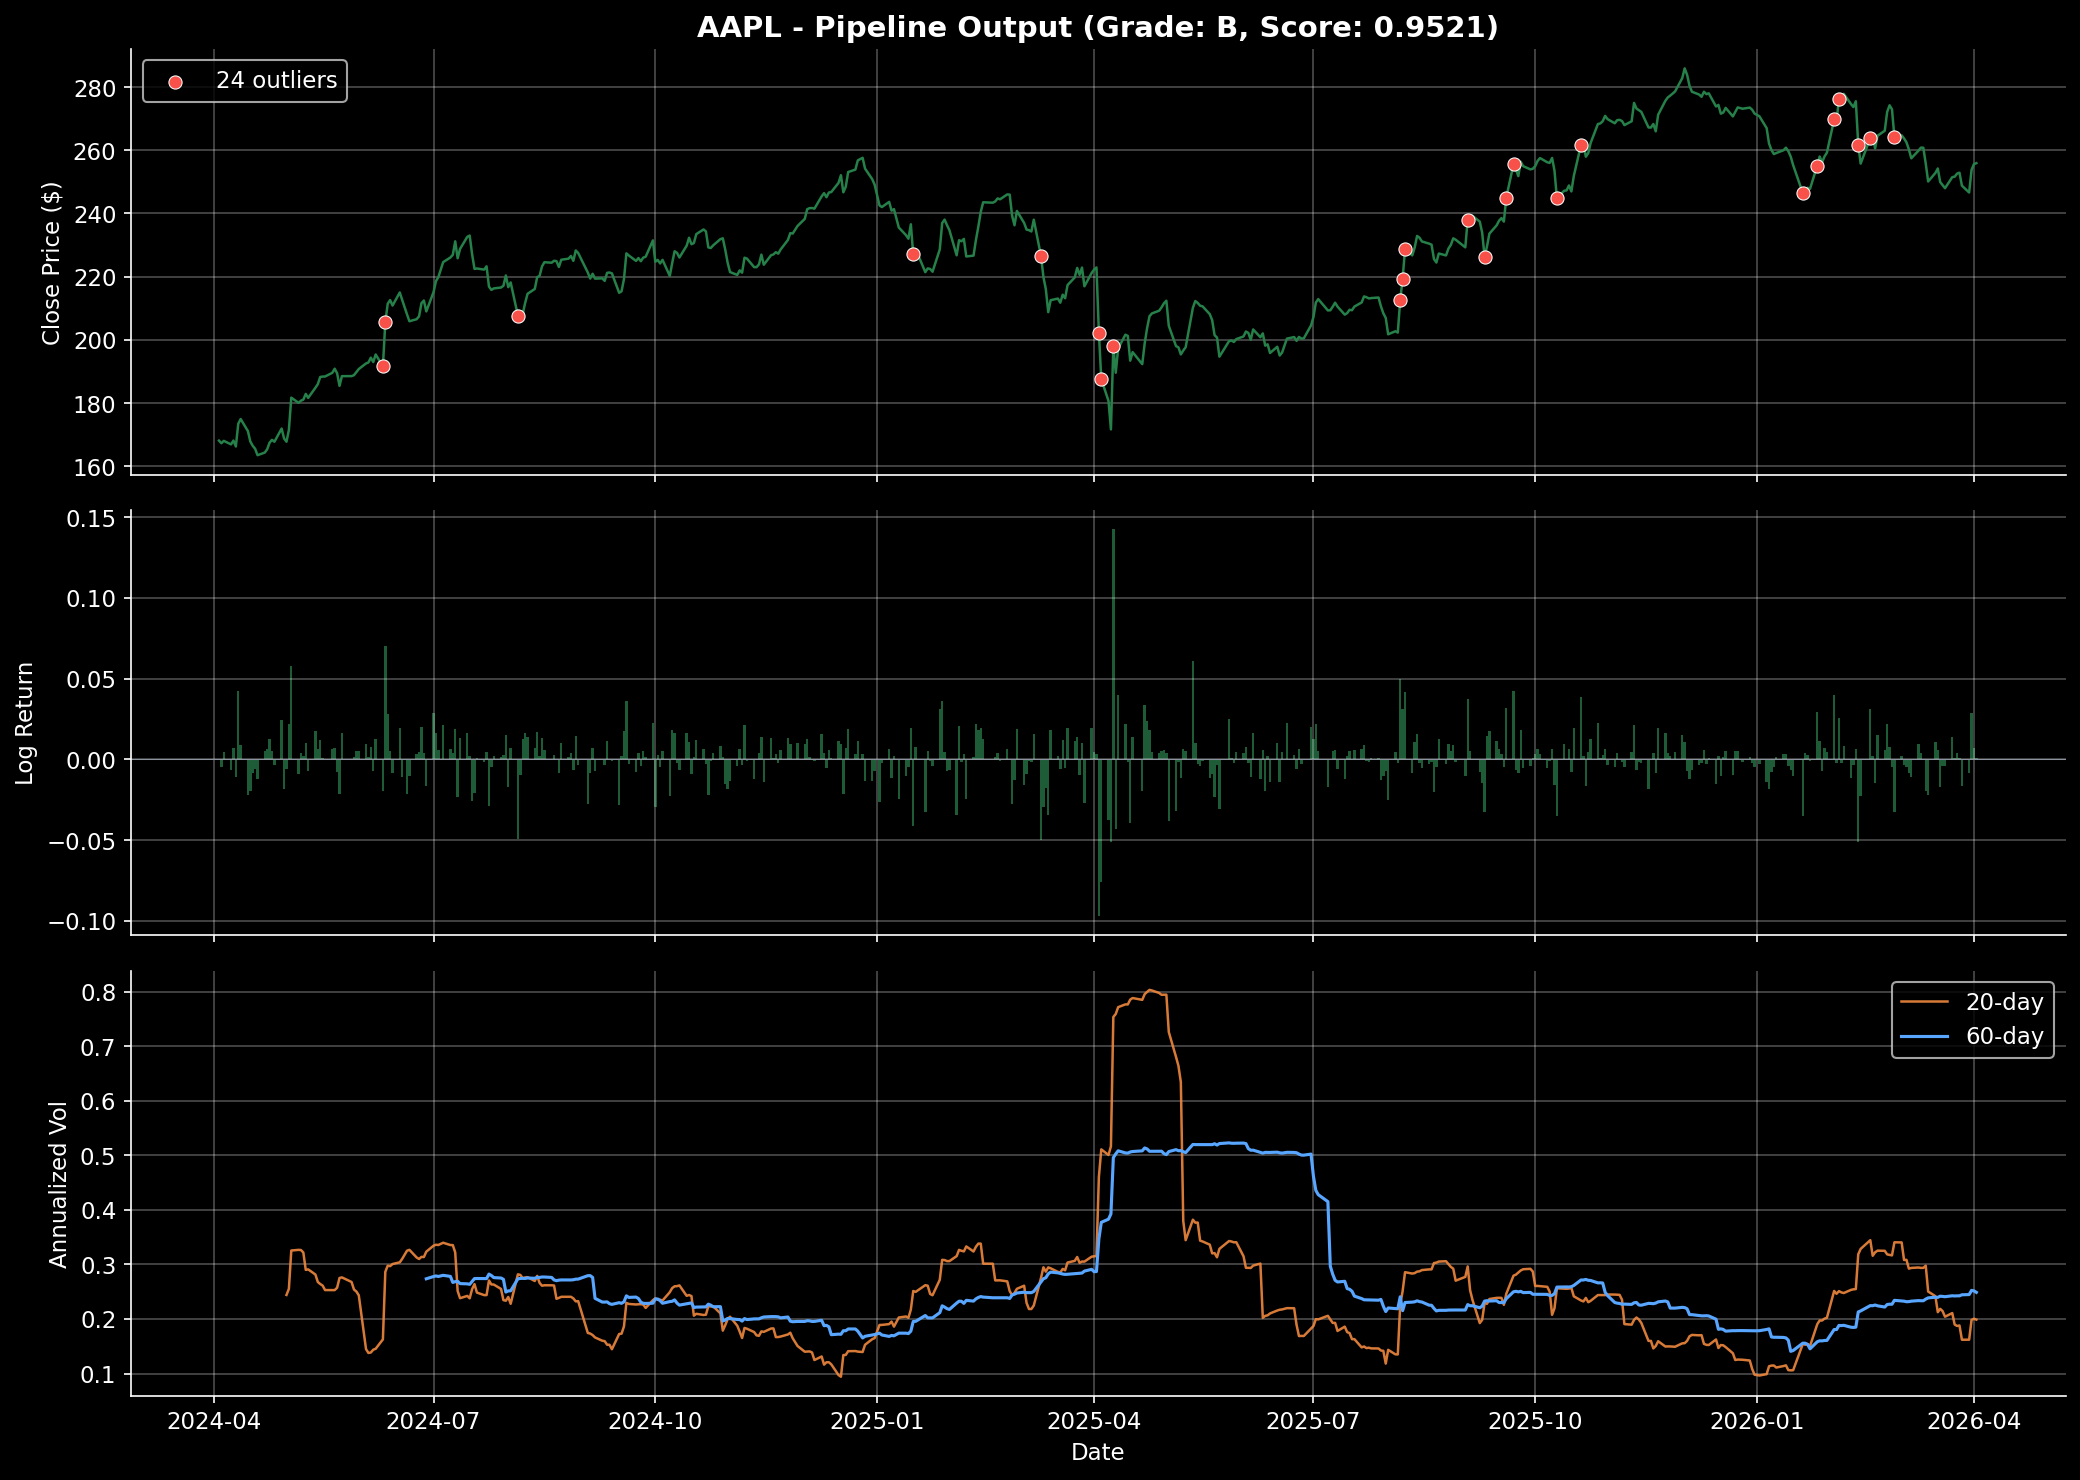

In [18]:
# Pipeline output visualization
clean = result['clean_data']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1. Clean price
axes[0].plot(clean.index, clean['Close'], color=COLORS['primary'], linewidth=1.2)
if result['report']['outliers_detected'] > 0:
    outlier_mask = clean.get('is_outlier', pd.Series(False, index=clean.index))
    outlier_idx = clean.index[outlier_mask == True]
    if len(outlier_idx) > 0:
        axes[0].scatter(outlier_idx, clean.loc[outlier_idx, 'Close'],
                       color=COLORS['red'], s=40, zorder=5, edgecolors='white',
                       linewidth=0.5, label=f'{len(outlier_idx)} outliers')
        axes[0].legend()
axes[0].set_ylabel('Close Price ($)')
axes[0].set_title(f'AAPL - Pipeline Output (Grade: {result["grade"]}, Score: {result["quality_score"]:.4f})',
                  fontweight='bold', fontsize=14)

# 2. Log returns
returns = clean['log_return'].dropna()
axes[1].bar(returns.index, returns, color=COLORS['secondary'], alpha=0.6, width=1)
axes[1].axhline(y=0, color=COLORS['gray'], linewidth=0.5)
axes[1].set_ylabel('Log Return')

# 3. Rolling volatility
vol_20 = returns.rolling(20).std() * np.sqrt(252)
vol_60 = returns.rolling(60).std() * np.sqrt(252)
axes[2].plot(vol_20.index, vol_20, color=COLORS['orange'], linewidth=1.2,
            alpha=0.9, label='20-day')
axes[2].plot(vol_60.index, vol_60, color=COLORS['blue'], linewidth=1.5,
            label='60-day')
axes[2].set_ylabel('Annualized Vol')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.show()

## 9. Multi-Ticker Analysis

A production pipeline doesn't process one ticker at a time. It runs across thousands of instruments every morning. Let's run our pipeline on multiple stocks and compare quality metrics.

In [19]:
# Run pipeline on all tickers
results = {}
for ticker in tickers:
    results[ticker] = run_quality_pipeline(data[ticker])

# Summary table
print('MULTI-TICKER QUALITY REPORT')
print('=' * 75)
print(f'{"Ticker":<8} {"Grade":<6} {"Score":<8} {"Validity":<10} '
      f'{"Complete":<10} {"Outlier":<10} {"#Outliers":<10}')
print('-' * 75)
for ticker in tickers:
    r = results[ticker]
    rpt = r['report']
    print(f'{ticker:<8} {r["grade"]:<6} {r["quality_score"]:<8.4f} '
          f'{rpt["validity_score"]:<10.4f} {rpt["completeness_score"]:<10.4f} '
          f'{rpt["outlier_score"]:<10.4f} {rpt["outliers_detected"]:<10}')

MULTI-TICKER QUALITY REPORT
Ticker   Grade  Score    Validity   Complete   Outlier    #Outliers 
---------------------------------------------------------------------------
AAPL     B      0.9521   1.0000     1.0000     0.9521     24        
MSFT     B      0.9800   1.0000     1.0000     0.9800     10        
TSLA     B      0.9860   1.0000     1.0000     0.9860     7         
GOOG     B      0.9641   1.0000     1.0000     0.9641     18        


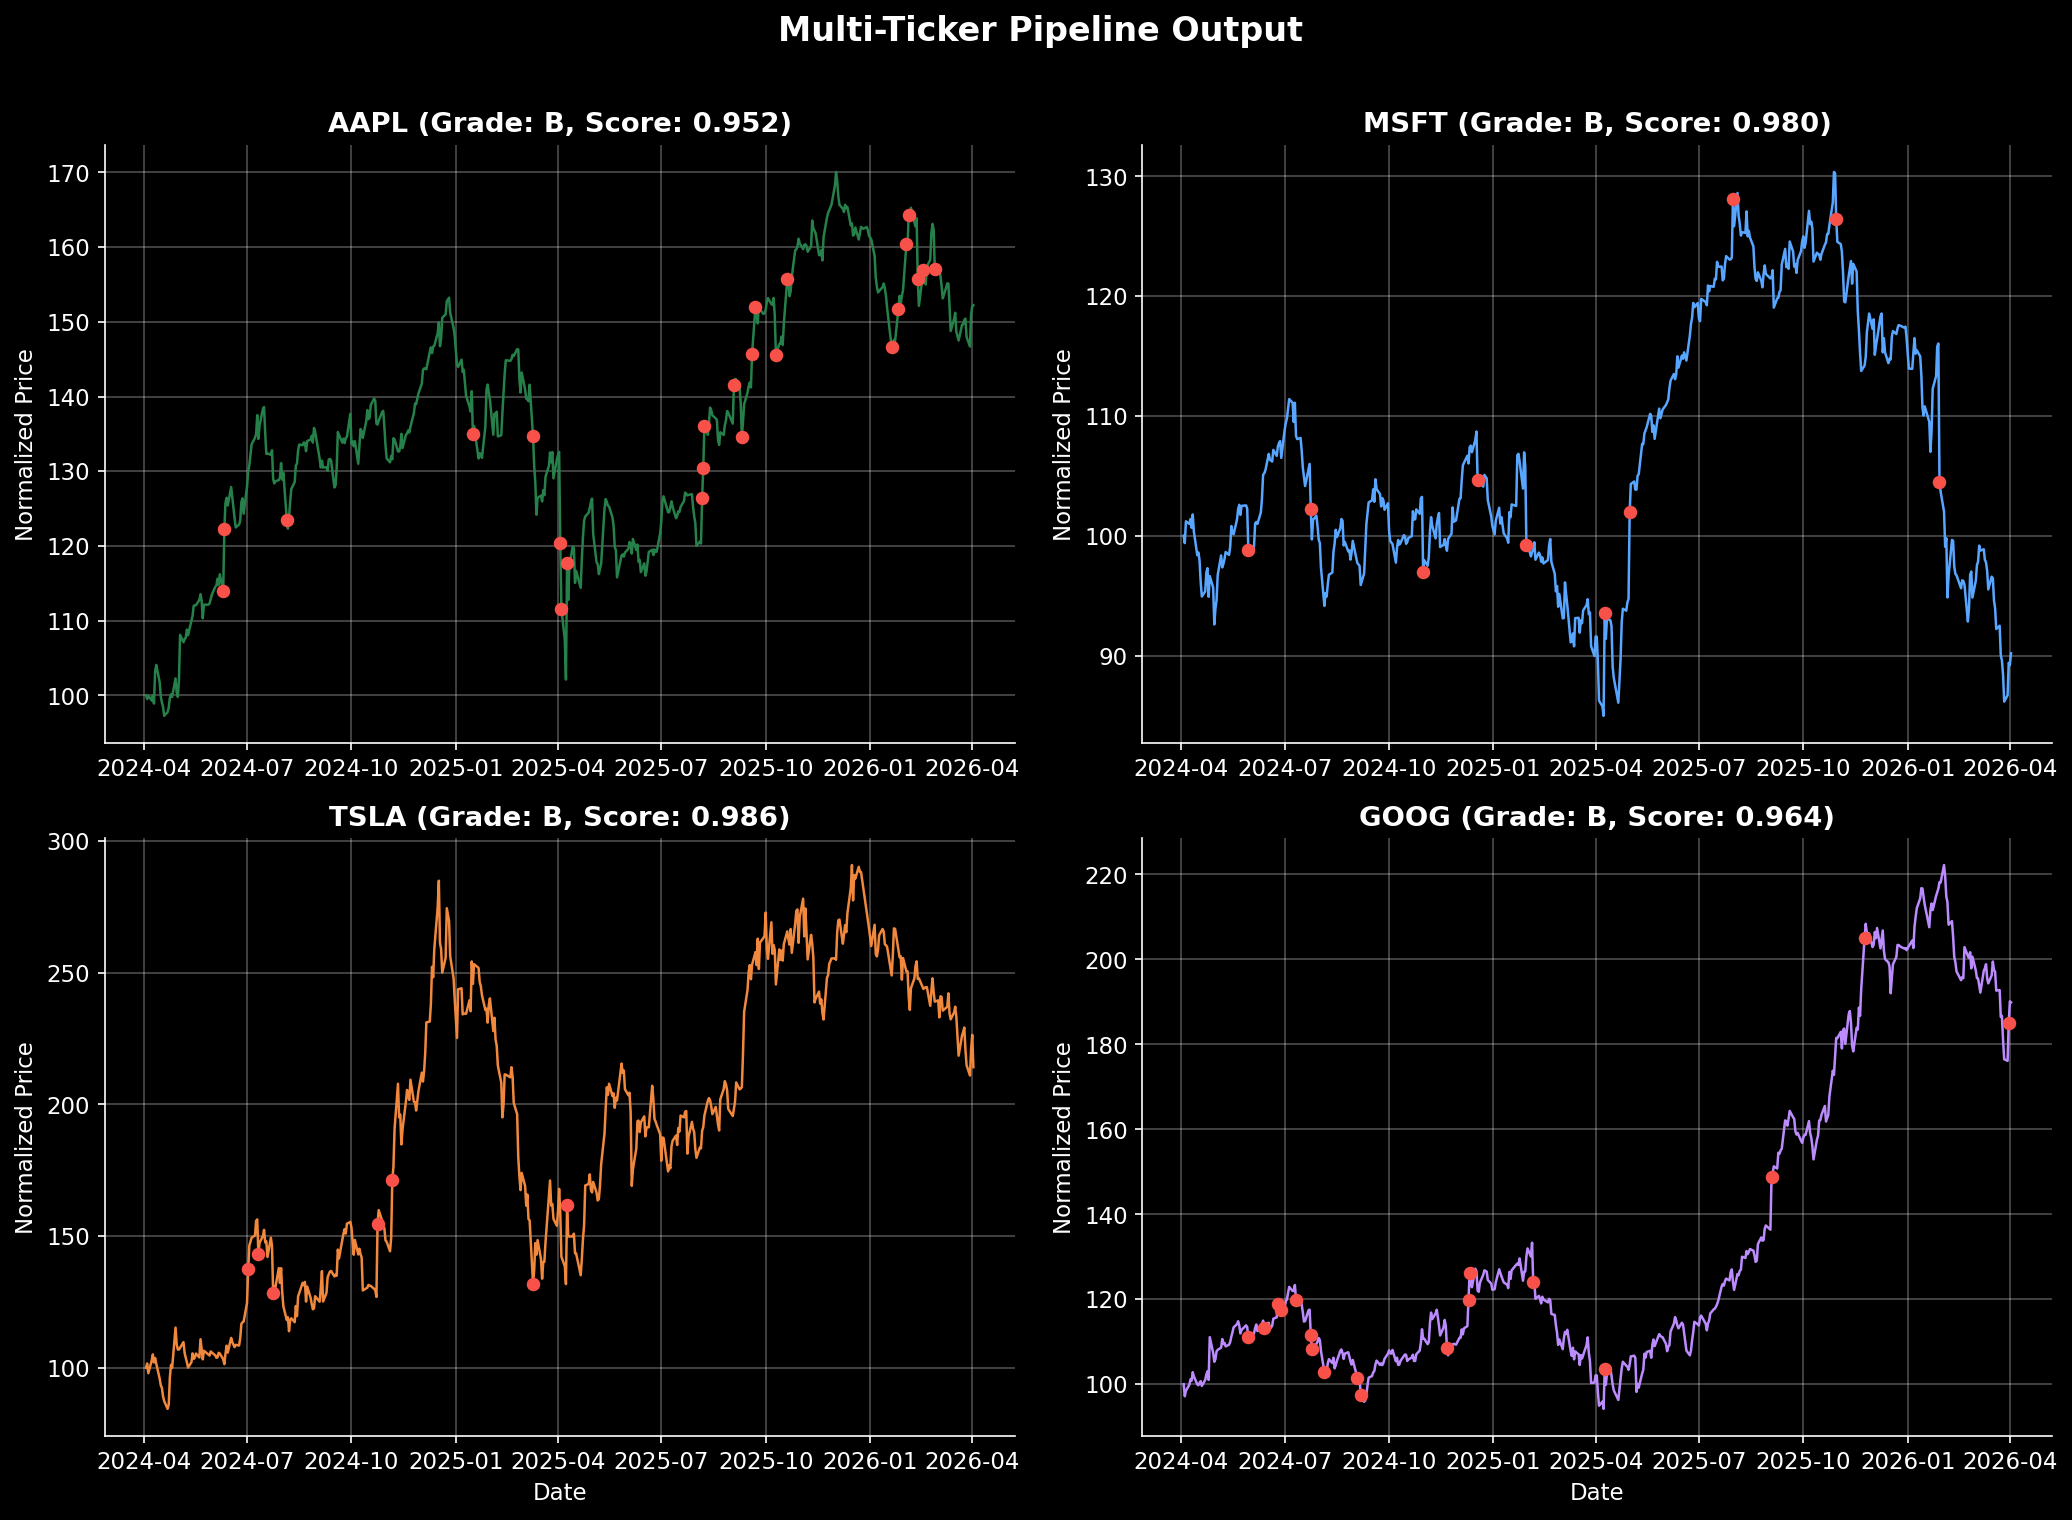

In [20]:
# Multi-ticker comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors_list = [COLORS['primary'], COLORS['blue'], COLORS['orange'], COLORS['purple']]

for i, ticker in enumerate(tickers):
    row, col = divmod(i, 2)
    ax = axes[row, col]
    
    clean_data = results[ticker]['clean_data']
    grade = results[ticker]['grade']
    score = results[ticker]['quality_score']
    
    # Normalize to 100 for comparison
    normalized = clean_data['Close'] / clean_data['Close'].iloc[0] * 100
    ax.plot(clean_data.index, normalized, color=colors_list[i], linewidth=1.2)
    
    # Mark outliers
    if 'is_outlier' in clean_data.columns:
        outlier_mask = clean_data['is_outlier'] == True
        if outlier_mask.any():
            outlier_idx = clean_data.index[outlier_mask]
            ax.scatter(outlier_idx, normalized.loc[outlier_idx],
                      color=COLORS['red'], s=30, zorder=5)
    
    ax.set_title(f'{ticker} (Grade: {grade}, Score: {score:.3f})', fontweight='bold')
    ax.set_ylabel('Normalized Price')
    if row == 1:
        ax.set_xlabel('Date')

plt.suptitle('Multi-Ticker Pipeline Output', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Cross-asset return statistics and fat-tails comparison
print('RETURN STATISTICS COMPARISON')
print('=' * 80)
print(f'{"Ticker":<8} {"Ann. Return":<14} {"Ann. Vol":<12} {"Sharpe":<10} '
      f'{"Skewness":<10} {"Kurtosis":<10} {"Max DD":<10}')
print('-' * 80)

for ticker in tickers:
    clean_data = results[ticker]['clean_data']
    ret = clean_data['log_return'].dropna()
    
    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    skew = ret.skew()
    kurt = ret.kurtosis()
    
    # Max drawdown
    cum_ret = (1 + clean_data['simple_return'].fillna(0)).cumprod()
    running_max = cum_ret.cummax()
    drawdown = (cum_ret - running_max) / running_max
    max_dd = drawdown.min()
    
    print(f'{ticker:<8} {ann_ret:<14.2%} {ann_vol:<12.2%} {sharpe:<10.2f} '
          f'{skew:<10.3f} {kurt:<10.2f} {max_dd:<10.2%}')

print(f'\nAll tickers show excess kurtosis >> 0, confirming fat tails.')
print(f'This validates our choice of MAD over standard z-scores for outlier detection.')

RETURN STATISTICS COMPARISON
Ticker   Ann. Return    Ann. Vol     Sharpe     Skewness   Kurtosis   Max DD    
--------------------------------------------------------------------------------
AAPL     21.14%         28.17%       0.75       0.578      10.98      -33.36%   
MSFT     -5.20%         24.23%       -0.21      -0.381     9.06       -33.91%   
TSLA     38.30%         61.96%       0.62       0.372      3.83       -53.77%   
GOOG     32.25%         29.53%       1.09       0.309      3.95       -29.35%   

All tickers show excess kurtosis >> 0, confirming fat tails.
This validates our choice of MAD over standard z-scores for outlier detection.


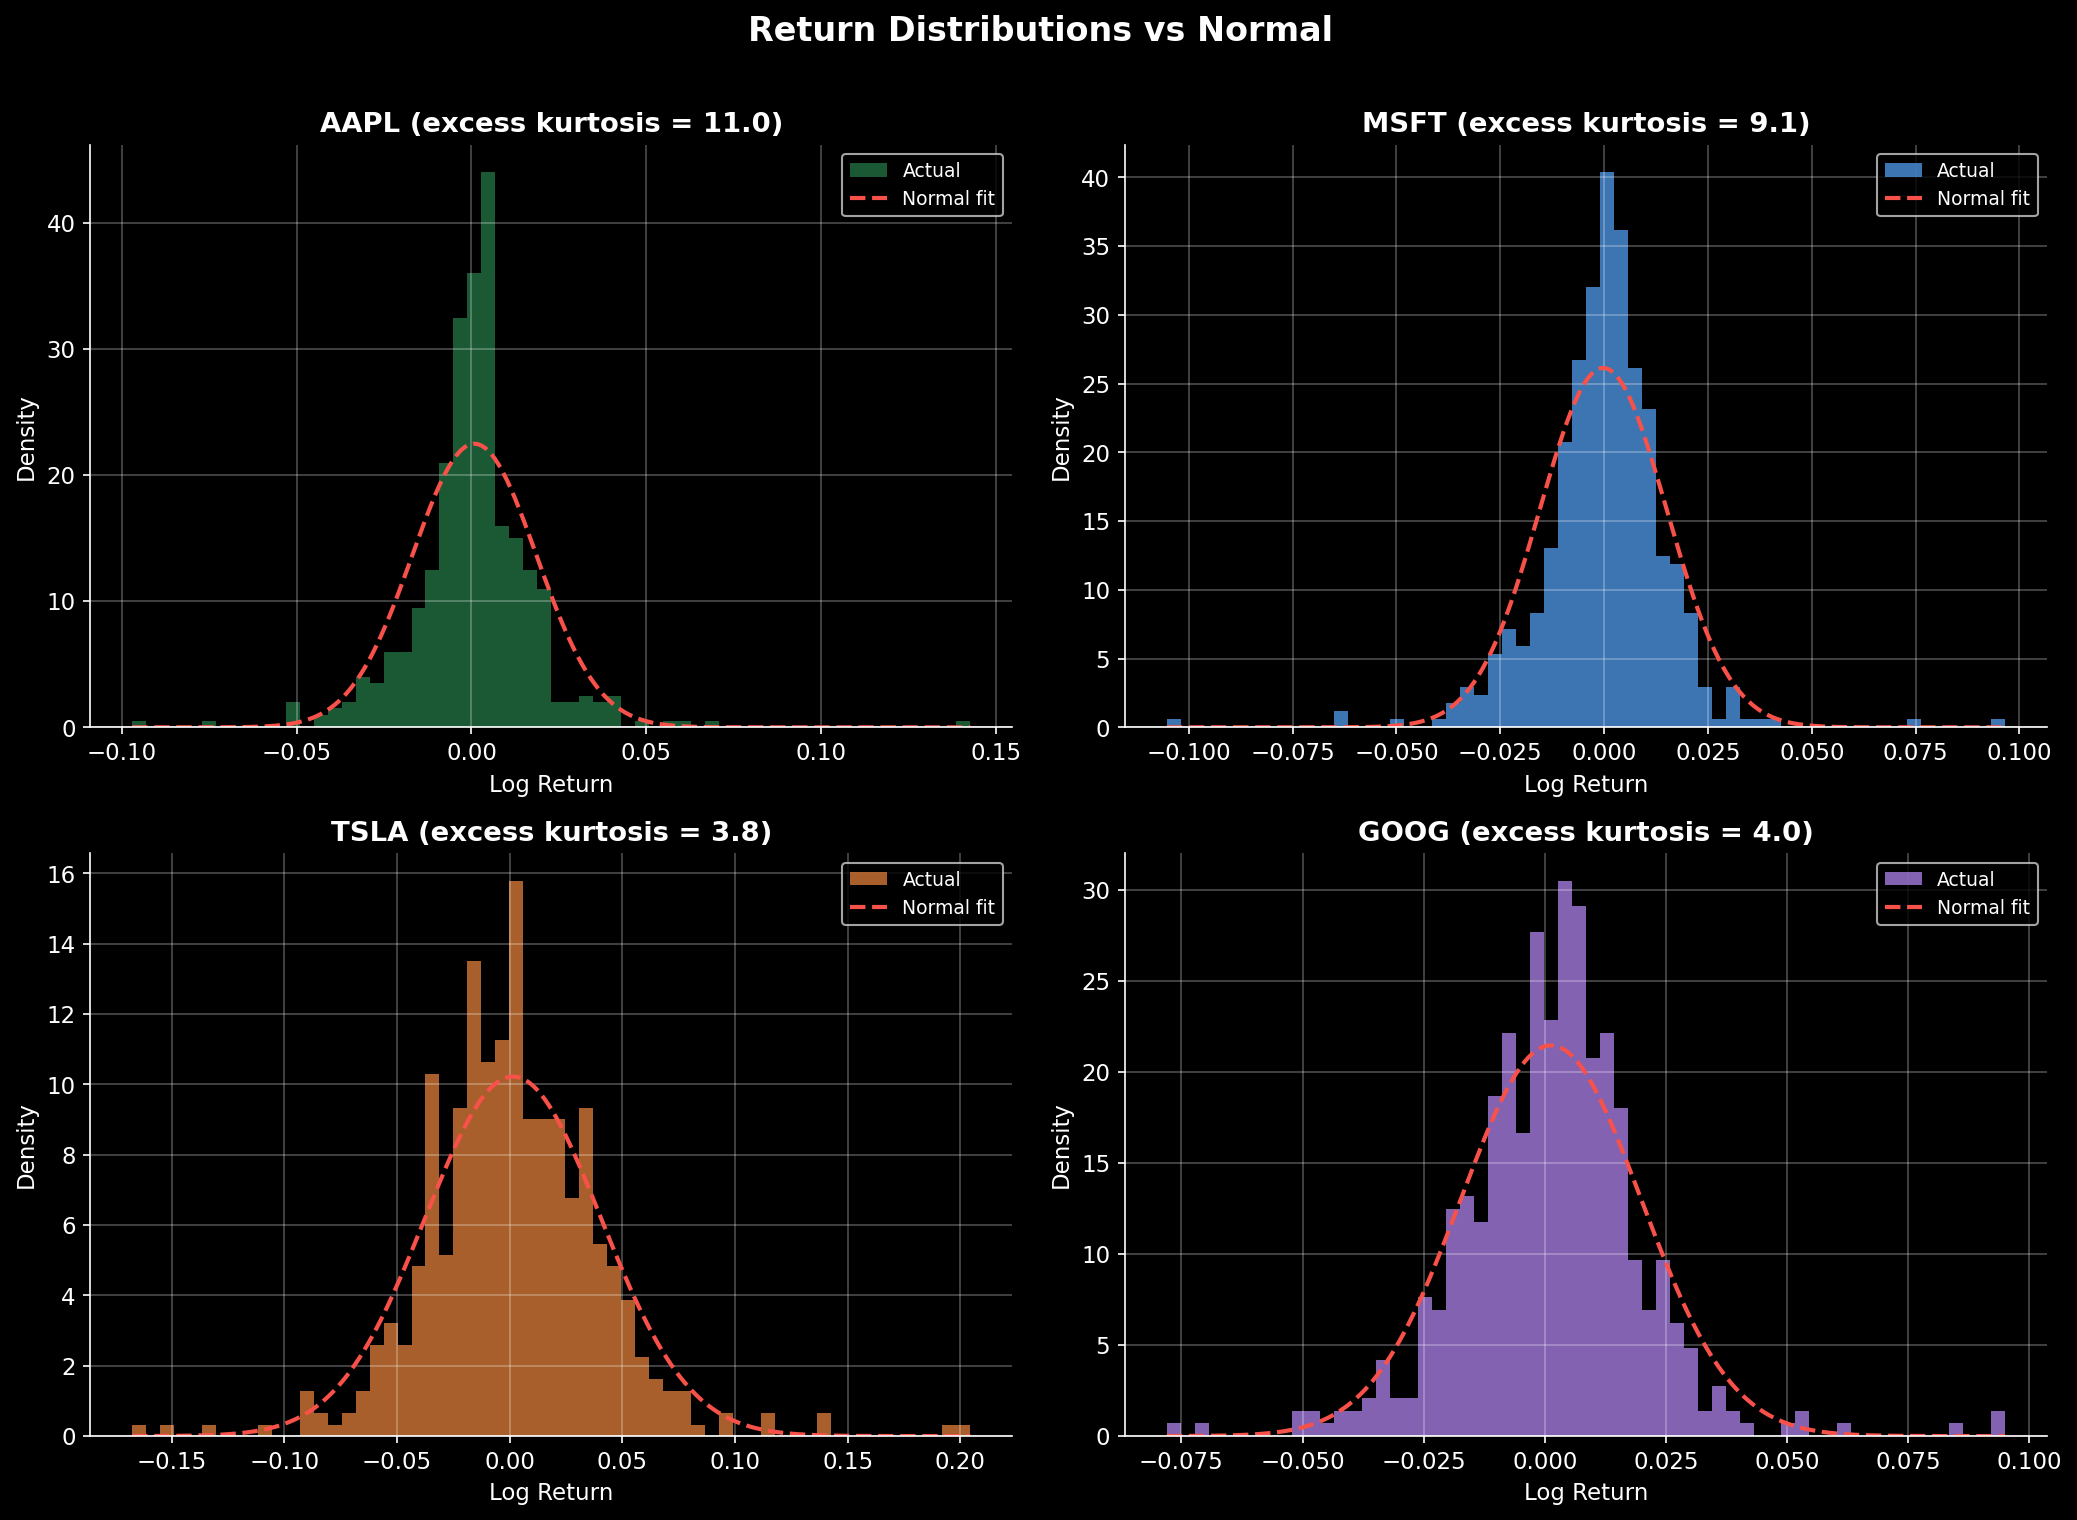

In [22]:
# Return distribution comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, ticker in enumerate(tickers):
    row, col = divmod(i, 2)
    ax = axes[row, col]
    
    ret = results[ticker]['clean_data']['log_return'].dropna()
    
    ax.hist(ret, bins=60, density=True, alpha=0.7, color=colors_list[i],
            edgecolor='none', label='Actual')
    x_range = np.linspace(ret.min(), ret.max(), 200)
    normal_pdf = stats.norm.pdf(x_range, ret.mean(), ret.std())
    ax.plot(x_range, normal_pdf, color=COLORS['red'], linewidth=2,
            linestyle='--', label='Normal fit')
    
    kurt = ret.kurtosis()
    ax.set_title(f'{ticker} (excess kurtosis = {kurt:.1f})', fontweight='bold')
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Return Distributions vs Normal', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. Todo

1. Multi-Source Reconciliation
2. Incorporate event calendar
3. Database storage